# Phase 7: Multi-Model Evaluation — 5-Shot Comparison

Compares **openai:o4-mini**, **ollama:mistral-nemo**, and **ollama:openbiollm** on the 5-shot run against the 180-record annotated ground truth set.  
Primary metric: `combined_score` (completeness-aware semantic similarity for free-text fields + F1 for TNM fields).

Sections:
1. Setup & Load Results
2. Per-Field Metrics
3. Stratified Results (cancer type / report style)
4. Model Comparison Matrix
5. Business Success Criteria Assessment
6. HITL Tier Distribution
7. OOV Investigation
8. Prediction Distribution Analysis (value frequencies, distributions, vocabulary coverage)
9. Semantic Similarity
10. Hallucination Flag Analysis
11. Field-Level Failure Heatmap
12. Cross-Model Agreement
13. Failure Patterns by Covariate
14. Record Inspector: GT vs Prediction


## 1. Setup & Load Results

In [154]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Project root (notebooks/ is one level below root)
ROOT = Path(".").resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.evaluation.hitl_thresholds import tier_distribution
from src.evaluation.metrics import (
    ALL_FIELDS,
    FIELD_WEIGHTS,
    SEMANTIC_FIELDS,
    compute_aggregate_metrics,
    compute_all_field_metrics,
    compute_combined_score,
    compute_semantic_metrics,
)
from src.evaluation.model_comparison import build_comparison_matrix
from src.evaluation.stratifier import (
    attach_style,
    compute_stratified_metrics,
    load_style_lookup,
    stratify,
)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

In [155]:
def load_jsonl(path) -> list[dict]:
    records = []
    with open(path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records


# Ground truth
ground_truth = load_jsonl(ROOT / "data/annotations/eval_set_v2.jsonl")

# Pipeline results — 5-shot runs
results_o4mini_path     = ROOT / "data/processed/eval_results_o4mini_5shot.jsonl"
results_llama3_path     = ROOT / "data/processed/eval_results_mistral_nemo_5shot.jsonl"
results_openbiollm_path = ROOT / "data/processed/eval_results_openbiollm_2shot_v18.jsonl"

preds_o4mini     = load_jsonl(results_o4mini_path)     if results_o4mini_path.exists()     else []
preds_llama3     = load_jsonl(results_llama3_path)     if results_llama3_path.exists()     else []
preds_openbiollm = load_jsonl(results_openbiollm_path) if results_openbiollm_path.exists() else []

# Style lookup from pilot corpus
style_lookup = load_style_lookup(ROOT / "data/processed/pilot_corpus_v1.jsonl")

# Attach style to ground truth and predictions
ground_truth_styled     = attach_style(ground_truth,    style_lookup)
preds_o4mini_styled     = attach_style(preds_o4mini,    style_lookup)
preds_llama3_styled     = attach_style(preds_llama3,    style_lookup)
preds_openbiollm_styled = attach_style(preds_openbiollm, style_lookup)

print(f"Ground truth records  : {len(ground_truth)}")
print(f"o4-mini predictions   : {len(preds_o4mini)}")
print(f"mistral-nemo preds    : {len(preds_llama3)}")
print(f"openbiollm preds      : {len(preds_openbiollm)}")


Ground truth records  : 180
o4-mini predictions   : 180
mistral-nemo preds    : 180
openbiollm preds      : 180


In [156]:
def status_counts(preds: list[dict], label: str) -> "pd.DataFrame":
    if not preds:
        return pd.DataFrame(columns=["validation_status", "count", "model"])
    df = pd.DataFrame(preds)
    counts = df["validation_status"].value_counts().reset_index()
    counts.columns = ["validation_status", "count"]
    counts["model"] = label
    return counts

status_df = pd.concat([
    status_counts(preds_o4mini,     "openai:o4-mini"),
    status_counts(preds_llama3,     "ollama:mistral-nemo"),
    status_counts(preds_openbiollm, "ollama:openbiollm"),
], ignore_index=True)

display(status_df.pivot(index="validation_status", columns="model", values="count").fillna(0).astype(int))


model,ollama:mistral-nemo,ollama:openbiollm,openai:o4-mini
validation_status,,,
valid,154,173,179
vocab_flagged,26,7,1


## 2. Per-Field Metrics

In [157]:
DIFFICULTY = {
    "primary_site": "Low",
    "specimen_type": "Low",
    "histological_diagnosis": "Medium",
    "histological_subtype": "Medium",
    "tumor_grade": "Medium",
    "tnm_stage.T": "High",
    "tnm_stage.N": "High",
    "tnm_stage.M": "Low",
}


def field_metrics_df(preds: list[dict], label: str) -> "pd.DataFrame":
    if not preds:
        return pd.DataFrame()
    fm_list  = compute_all_field_metrics(preds, ground_truth)
    sem_list = compute_semantic_metrics(preds, ground_truth)
    sem_map          = {sm.field: round(sm.mean_similarity,          3) for sm in sem_list}
    sim_complete_map = {sm.field: round(sm.mean_similarity_complete, 3) for sm in sem_list}
    combined = round(compute_combined_score(fm_list, sem_list), 4)
    rows = []
    for fm in fm_list:
        sc = sim_complete_map.get(fm.field) if fm.field in SEMANTIC_FIELDS else round(fm.f1, 3)
        rows.append({
            "field":          fm.field,
            "difficulty":     DIFFICULTY.get(fm.field, "-"),
            "weight":         FIELD_WEIGHTS[fm.field],
            "precision":      round(fm.precision,    3),
            "recall":         round(fm.recall,       3),
            "f1":             round(fm.f1,           3),
            "similarity":     sem_map.get(fm.field),
            "sim_complete":   sim_complete_map.get(fm.field),
            "for_combined":   sc,
            "exact_match":    round(fm.exact_match,  3),
            "null_accuracy":  round(fm.null_accuracy, 3),
            "model":          label,
            "combined_score": None,
        })
    df = pd.DataFrame(rows)
    df.attrs["combined_score"] = combined
    df.attrs["model"] = label
    return df


fm_o4mini     = field_metrics_df(preds_o4mini,     "openai:o4-mini")
fm_llama3     = field_metrics_df(preds_llama3,     "ollama:mistral-nemo")
fm_openbiollm = field_metrics_df(preds_openbiollm, "ollama:openbiollm")

_DISPLAY_COLS = ["field", "difficulty", "precision", "recall", "f1",
                 "similarity", "sim_complete", "for_combined", "exact_match", "null_accuracy"]

for fm_df, caption in [
    (fm_o4mini,     "o4-mini  |  for_combined = sim_complete (semantic) or f1 (TNM)"),
    (fm_llama3,     "ollama:mistral-nemo  |  for_combined = sim_complete (semantic) or f1 (TNM)"),
    (fm_openbiollm, "ollama:openbiollm  |  for_combined = sim_complete (semantic) or f1 (TNM)"),
]:
    if fm_df.empty:
        continue
    combined_val = fm_df.attrs.get("combined_score")
    model_label  = fm_df.attrs.get("model", "")
    display(
        fm_df[_DISPLAY_COLS]
        .set_index("field")
        .style
        .background_gradient(subset=["f1"],           cmap="RdYlGn", vmin=0, vmax=1)
        .background_gradient(subset=["similarity"],   cmap="RdYlGn", vmin=0, vmax=1)
        .background_gradient(subset=["sim_complete"], cmap="RdYlGn", vmin=0, vmax=1)
        .background_gradient(subset=["for_combined"], cmap="RdYlGn", vmin=0, vmax=1)
        .format({
            "precision":    "{:.3f}", "recall":       "{:.3f}",
            "f1":           "{:.3f}", "exact_match":  "{:.3f}",
            "null_accuracy":"{:.3f}",
            "similarity":   lambda v: "" if v is None or (isinstance(v, float) and pd.isna(v)) else f"{v:.3f}",
            "sim_complete": lambda v: "" if v is None or (isinstance(v, float) and pd.isna(v)) else f"{v:.3f}",
        }, na_rep="")
        .set_caption(caption)
    )
    if combined_val is not None:
        print(f"{model_label}  →  combined_score = {combined_val:.4f}")


,difficulty,precision,recall,f1,similarity,sim_complete,for_combined,exact_match,null_accuracy
field,,,,,,,,,
primary_site,Low,0.814,0.814,0.814,0.963,0.964,0.964000,0.817,1.000
specimen_type,Low,0.773,0.773,0.773,0.948,0.917,0.917000,0.767,0.967
histological_diagnosis,Medium,0.881,0.876,0.879,0.982,0.977,0.977000,0.878,0.994
histological_subtype,Medium,0.692,0.592,0.638,0.937,0.830,0.830000,0.700,0.867
tumor_grade,Medium,0.528,0.512,0.520,0.957,0.933,0.933000,0.550,0.972
tnm_stage.T,High,0.829,0.824,0.827,,,0.827000,0.811,0.939
tnm_stage.N,High,0.855,0.855,0.855,,,0.855000,0.861,0.978
tnm_stage.M,Low,0.733,0.913,0.813,,,0.813000,0.867,0.894


openai:o4-mini  →  combined_score = 0.8815


,difficulty,precision,recall,f1,similarity,sim_complete,for_combined,exact_match,null_accuracy
field,,,,,,,,,
primary_site,Low,0.596,0.599,0.597,0.911,0.907,0.907000,0.600,0.994
specimen_type,Low,0.619,0.634,0.626,0.905,0.865,0.865000,0.617,0.956
histological_diagnosis,Medium,0.702,0.702,0.702,0.930,0.931,0.931000,0.706,1.000
histological_subtype,Medium,0.532,0.528,0.530,0.891,0.751,0.751000,0.583,0.817
tumor_grade,Medium,0.606,0.464,0.526,0.945,0.744,0.744000,0.506,0.783
tnm_stage.T,High,0.821,0.721,0.768,,,0.768000,0.722,0.844
tnm_stage.N,High,0.739,0.623,0.676,,,0.676000,0.656,0.839
tnm_stage.M,Low,0.650,0.565,0.605,,,0.605000,0.756,0.794


ollama:mistral-nemo  →  combined_score = 0.7707


,difficulty,precision,recall,f1,similarity,sim_complete,for_combined,exact_match,null_accuracy
field,,,,,,,,,
primary_site,Low,0.500,0.096,0.161,0.746,0.157,0.157000,0.111,0.206
specimen_type,Low,0.588,0.116,0.194,0.891,0.202,0.202000,0.150,0.222
histological_diagnosis,Medium,0.588,0.112,0.189,0.943,0.189,0.189000,0.122,0.200
histological_subtype,Medium,0.421,0.064,0.111,0.786,0.369,0.369000,0.339,0.389
tumor_grade,Medium,0.452,0.084,0.142,0.629,0.186,0.186000,0.156,0.250
tnm_stage.T,High,0.455,0.091,0.152,,,0.152000,0.167,0.267
tnm_stage.N,High,0.364,0.075,0.125,,,0.125000,0.183,0.300
tnm_stage.M,Low,0.417,0.072,0.123,,,0.123000,0.633,0.661


ollama:openbiollm  →  combined_score = 0.1867


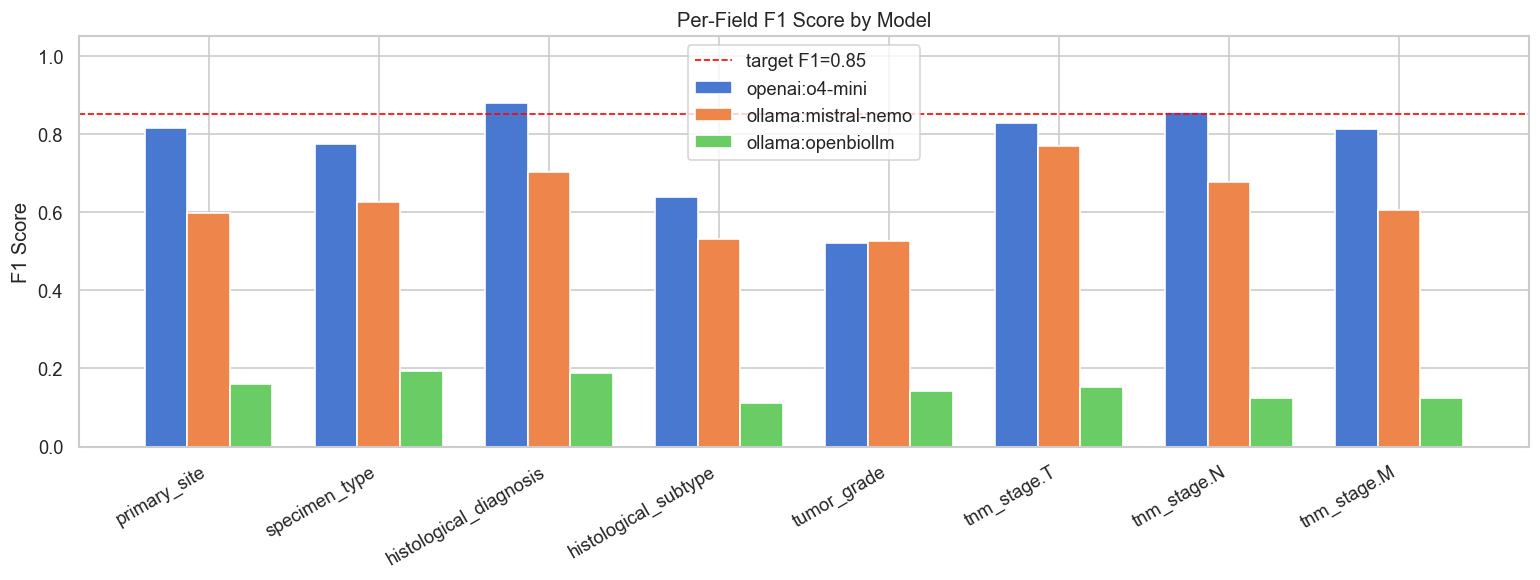

In [158]:
palette = {"Low": "#4CAF50", "Medium": "#FF9800", "High": "#F44336"}

all_fm = pd.concat([fm_o4mini, fm_llama3, fm_openbiollm], ignore_index=True)
if not all_fm.empty:
    fig, ax = plt.subplots(figsize=(13, 5))
    models = all_fm["model"].unique()
    x = range(len(ALL_FIELDS))
    width = 0.25
    for i, model in enumerate(models):
        sub = all_fm[all_fm["model"] == model].set_index("field")
        ax.bar(
            [xi + (i - 1) * width for xi in x],
            [sub.loc[f, "f1"] if f in sub.index else 0 for f in ALL_FIELDS],
            width, label=model,
        )
    ax.set_xticks([xi for xi in x])
    ax.set_xticklabels(ALL_FIELDS, rotation=30, ha="right")
    ax.set_ylabel("F1 Score")
    ax.set_ylim(0, 1.05)
    ax.axhline(0.85, color="red", linestyle="--", linewidth=1, label="target F1=0.85")
    ax.legend()
    ax.set_title("Per-Field F1 Score by Model")
    plt.tight_layout()
    plt.show()


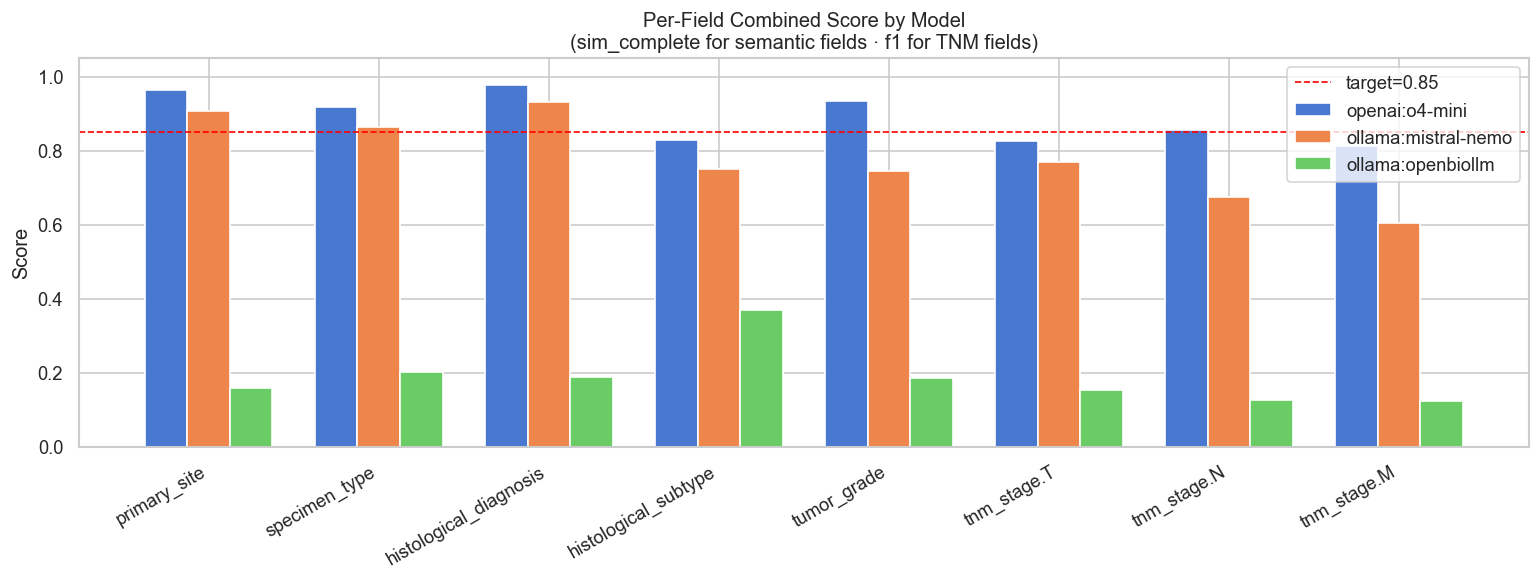

In [159]:
all_fm = pd.concat([fm_o4mini, fm_llama3, fm_openbiollm], ignore_index=True)

if not all_fm.empty:
    models = all_fm["model"].unique()
    x = range(len(ALL_FIELDS))
    width = 0.25

    fig, ax = plt.subplots(figsize=(13, 5))
    for i, model in enumerate(models):
        sub = all_fm[all_fm["model"] == model].set_index("field")
        ax.bar(
            [xi + (i - 1) * width for xi in x],
            [sub.loc[f, "for_combined"] if f in sub.index and sub.loc[f, "for_combined"] is not None else 0
             for f in ALL_FIELDS],
            width, label=model,
        )
    ax.set_xticks([xi for xi in x])
    ax.set_xticklabels(ALL_FIELDS, rotation=30, ha="right")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.05)
    ax.axhline(0.85, color="red", linestyle="--", linewidth=1, label="target=0.85")
    ax.legend()
    ax.set_title("Per-Field Combined Score by Model\n(sim_complete for semantic fields · f1 for TNM fields)")
    plt.tight_layout()
    plt.show()


## 3. Stratified Results

In [160]:
def stratified_mixed_df(preds_styled, golds_styled, by, model_label):
    """Stratified scores per stratum.

    mixed_score   : unweighted avg of co-present similarity (semantic) and F1 (TNM) — legacy
    combined_score: weighted avg using sim_complete (semantic, penalises nulls) and F1 (TNM)
    """
    if not preds_styled:
        return pd.DataFrame()
    gold_groups = stratify(golds_styled, by)
    pred_map    = {r["report_id"]: r for r in preds_styled}
    rows = []
    for stratum, stratum_golds in sorted(gold_groups.items()):
        rids          = {r["report_id"] for r in stratum_golds}
        stratum_preds = [pred_map[rid] for rid in rids if rid in pred_map]
        if not stratum_golds:
            continue
        fm_list  = compute_all_field_metrics(stratum_preds, stratum_golds)
        sem_list = compute_semantic_metrics(stratum_preds, stratum_golds)
        # legacy mixed: unweighted, co-present similarity
        fm_dict  = {fm.field: fm.f1             for fm in fm_list}
        sem_dict = {sm.field: sm.mean_similarity for sm in sem_list}
        scores   = [
            sem_dict.get(f, 0.0) if f in SEMANTIC_FIELDS else fm_dict.get(f, 0.0)
            for f in ALL_FIELDS
        ]
        mixed    = round(sum(scores) / len(scores), 3)
        combined = round(compute_combined_score(fm_list, sem_list), 3)
        rows.append({
            "stratum":        stratum,
            "mixed_score":    mixed,
            "combined_score": combined,
            "n_records":      len(stratum_golds),
            "model":          model_label,
        })
    return pd.DataFrame(rows).sort_values("stratum")


# Cancer type
mixed_ct_o4  = stratified_mixed_df(preds_o4mini_styled,     ground_truth_styled, "cancer_type", "openai:o4-mini")
mixed_ct_ll  = stratified_mixed_df(preds_llama3_styled,     ground_truth_styled, "cancer_type", "ollama:mistral-nemo")
mixed_ct_ob  = stratified_mixed_df(preds_openbiollm_styled, ground_truth_styled, "cancer_type", "ollama:openbiollm")
mixed_ct_all = pd.concat([mixed_ct_o4, mixed_ct_ll, mixed_ct_ob], ignore_index=True)

if not mixed_ct_all.empty:
    for metric, caption in [
        ("combined_score", "Combined score by cancer type  (weighted · sim_complete for semantic · F1 for TNM)"),
        ("mixed_score",    "Mixed score by cancer type — legacy  (unweighted · co-present similarity · F1 for TNM)"),
    ]:
        pivot = mixed_ct_all.pivot(index="stratum", columns="model", values=metric)
        display(
            pivot.style
            .background_gradient(cmap="RdYlGn", vmin=0, vmax=1)
            .format(precision=3)
            .set_caption(caption)
        )

model,ollama:mistral-nemo,ollama:openbiollm,openai:o4-mini
stratum,,,
BRCA,0.776,0.158,0.870
LUAD,0.769,0.174,0.907
LUSC,0.740,0.259,0.876


model,ollama:mistral-nemo,ollama:openbiollm,openai:o4-mini
stratum,,,
BRCA,0.800,0.515,0.903
LUAD,0.864,0.552,0.922
LUSC,0.818,0.654,0.910


In [161]:
mixed_rs_o4  = stratified_mixed_df(preds_o4mini_styled,     ground_truth_styled, "report_style", "openai:o4-mini")
mixed_rs_ll  = stratified_mixed_df(preds_llama3_styled,     ground_truth_styled, "report_style", "ollama:mistral-nemo")
mixed_rs_ob  = stratified_mixed_df(preds_openbiollm_styled, ground_truth_styled, "report_style", "ollama:openbiollm")
mixed_rs_all = pd.concat([mixed_rs_o4, mixed_rs_ll, mixed_rs_ob], ignore_index=True)

if not mixed_rs_all.empty:
    for metric, caption in [
        ("combined_score", "Combined score by report style  (weighted · sim_complete for semantic · F1 for TNM)"),
        ("mixed_score",    "Mixed score by report style — legacy  (unweighted · co-present similarity · F1 for TNM)"),
    ]:
        pivot = mixed_rs_all.pivot(index="stratum", columns="model", values=metric)
        display(
            pivot.style
            .background_gradient(cmap="RdYlGn", vmin=0, vmax=1)
            .format(precision=3)
            .set_caption(caption)
        )


model,ollama:mistral-nemo,ollama:openbiollm,openai:o4-mini
stratum,,,
mixed,0.755,0.157,0.884
narrative,0.781,0.407,0.871
synoptic,0.785,0.179,0.880


model,ollama:mistral-nemo,ollama:openbiollm,openai:o4-mini
stratum,,,
mixed,0.827,0.468,0.916
narrative,0.801,0.643,0.928
synoptic,0.833,0.585,0.899


In [162]:
model_results = {}
if preds_o4mini:
    model_results["openai:o4-mini"] = preds_o4mini
if preds_llama3:
    model_results["ollama:mistral-nemo"] = preds_llama3
if preds_openbiollm:
    model_results["ollama:openbiollm"] = preds_openbiollm

if model_results:
    matrix = build_comparison_matrix(model_results, ground_truth)
    display(
        matrix.set_index("model")
        .style
        .background_gradient(subset=["combined_score"],           cmap="RdYlGn",   vmin=0, vmax=1)
        .background_gradient(subset=["weighted_f1"],              cmap="RdYlGn",   vmin=0, vmax=1)
        .background_gradient(subset=["mean_similarity"],          cmap="RdYlGn",   vmin=0, vmax=1)
        .background_gradient(subset=["mean_similarity_complete"], cmap="RdYlGn",   vmin=0, vmax=1)
        .background_gradient(subset=["hallucination_rate"],       cmap="RdYlGn_r", vmin=0, vmax=0.1)
        .format({
            "combined_score":           "{:.4f}",
            "weighted_f1":              "{:.4f}",
            "mean_similarity":          "{:.4f}",
            "mean_similarity_complete": "{:.4f}",
            "hallucination_rate":       "{:.4f}",
            "avg_cost_per_record":      "${:.6f}",
            "avg_latency_ms":           "{:.0f} ms",
        })
        .set_caption("Model Comparison Scoring Matrix")
    )
else:
    print("No model results loaded yet — run the pipeline first.")


,combined_score,weighted_f1,mean_similarity,mean_similarity_complete,hallucination_rate,avg_cost_per_record,gdpr_compliant,avg_latency_ms
model,,,,,,,,
openai:o4-mini,0.8815,0.7680,0.9573,0.9244,0.0056,$0.015758,False,11676 ms
ollama:mistral-nemo,0.7707,0.6450,0.9163,0.8397,0.1556,$0.000000,True,17223 ms
ollama:openbiollm,0.1867,0.1461,0.7990,0.2208,0.0389,$0.000000,True,6761 ms


# Thresholds from specs/mission.md
THRESHOLD_F1_LOW = 0.89
THRESHOLD_F1_MED = 0.83
THRESHOLD_F1_HIGH = 0.87
THRESHOLD_HALLUCINATION = 0.05
THRESHOLD_PIPELINE_RELIABILITY = 0.95

_DIFF_THRESHOLDS = {"Low": THRESHOLD_F1_LOW, "Medium": THRESHOLD_F1_MED, "High": THRESHOLD_F1_HIGH}


def assess_primary(preds, golds, model_label):
    """Per-field F1 and similarity thresholds by difficulty. Returns (all_pass_f1, all_pass_sim)."""
    if not preds:
        return None
    metrics = {fm.field: fm for fm in compute_all_field_metrics(preds, golds)}
    sem_map = {sm.field: sm.mean_similarity for sm in compute_semantic_metrics(preds, golds)}
    rows = []
    all_pass_f1 = True
    all_pass_sim = True  # only considers SEMANTIC_FIELDS
    for field, fm in metrics.items():
        diff = DIFFICULTY[field]
        threshold = _DIFF_THRESHOLDS[diff]
        passed_f1 = fm.f1 >= threshold
        all_pass_f1 = all_pass_f1 and passed_f1
        if field in SEMANTIC_FIELDS:
            sim = sem_map.get(field)
            passed_sim = (sim is not None and sim >= threshold)
            all_pass_sim = all_pass_sim and passed_sim
            sim_str = f"{sim:.3f}" if sim is not None else "N/A"
            pass_sim_str = "✓" if passed_sim else "✗"
        else:
            sim_str = "N/A"
            pass_sim_str = "N/A"
        rows.append({
            "field": field,
            "difficulty": diff,
            "f1": round(fm.f1, 3),
            "similarity": sim_str,
            "threshold": threshold,
            "pass_f1": "✓" if passed_f1 else "✗",
            "pass_sim": pass_sim_str,
        })
    df = pd.DataFrame(rows).set_index("field")
    overall_f1 = "PASS" if all_pass_f1 else "FAIL"
    overall_sim = "PASS" if all_pass_sim else "FAIL"
    print(f"\n[{model_label}] PRIMARY criterion — F1: {overall_f1} | Similarity: {overall_sim}")
    display(df)
    return all_pass_f1, all_pass_sim


def assess_secondary(preds, model_label):
    """Hallucination rate ≤ 5%."""
    if not preds:
        return None
    from src.evaluation.metrics import compute_hallucination_rate
    rate = compute_hallucination_rate(preds)
    passed = rate <= THRESHOLD_HALLUCINATION
    status = "PASS" if passed else "FAIL"
    print(f"[{model_label}] SECONDARY criterion (hallucination ≤ 5%): {status} — rate={rate:.2%}")
    return passed


def assess_tertiary(preds, model_label):
    """Pipeline reliability ≥ 95% (records passing all 3 validation layers)."""
    if not preds:
        return None
    valid = sum(1 for r in preds if r.get("validation_status") == "valid")
    rate = valid / len(preds) if preds else 0
    passed = rate >= THRESHOLD_PIPELINE_RELIABILITY
    status = "PASS" if passed else "FAIL"
    print(f"[{model_label}] TERTIARY criterion (reliability ≥ 95%): {status} — {valid}/{len(preds)} valid ({rate:.2%})")
    return passed


for preds, label in [(preds_o4mini, "openai:o4-mini"), (preds_llama3, "ollama:llama3.2")]:
    if not preds:
        print(f"\n[{label}] — no results loaded")
        continue
    assess_primary(preds, ground_truth, label)
    assess_secondary(preds, label)
    assess_tertiary(preds, label)

In [163]:
F1_THRESHOLD       = 0.85
SIM_THRESHOLD      = 0.85
COMBINED_THRESHOLD = 0.80

summary_rows = []
for preds, label in [(preds_o4mini, "openai:o4-mini"), (preds_llama3, "ollama:mistral-nemo"), (preds_openbiollm, "ollama:openbiollm")]:
    if not preds:
        continue
    agg     = compute_aggregate_metrics(preds, ground_truth)
    sem     = compute_semantic_metrics(preds, ground_truth)
    fm_list = compute_all_field_metrics(preds, ground_truth)
    mean_sim          = sum(s.mean_similarity          for s in sem) / len(sem) if sem else 0.0
    mean_sim_complete = sum(s.mean_similarity_complete for s in sem) / len(sem) if sem else 0.0
    combined          = compute_combined_score(fm_list, sem)
    summary_rows.append({
        "model":             label,
        "weighted_F1":       round(agg.weighted_f1, 4),
        "mean_similarity":   round(mean_sim, 4),
        "mean_sim_complete": round(mean_sim_complete, 4),
        "combined_score":    round(combined, 4),
        "passed_f1":         "✓ pass" if agg.weighted_f1 >= F1_THRESHOLD       else "✗ fail",
        "passed_sim":        "✓ pass" if mean_sim          >= SIM_THRESHOLD     else "✗ fail",
        "passed_combined":   "✓ pass" if combined           >= COMBINED_THRESHOLD else "✗ fail",
    })

summary_df = pd.DataFrame(summary_rows).set_index("model")


def _pass_style(col: pd.Series) -> list[str]:
    return [
        "color: green; font-weight: bold" if v == "✓ pass"
        else ("color: red; font-weight: bold" if v == "✗ fail" else "")
        for v in col
    ]


display(
    summary_df.style
    .background_gradient(subset=["weighted_F1"],        cmap="RdYlGn", vmin=0, vmax=1)
    .background_gradient(subset=["mean_similarity"],    cmap="RdYlGn", vmin=0, vmax=1)
    .background_gradient(subset=["mean_sim_complete"],  cmap="RdYlGn", vmin=0, vmax=1)
    .background_gradient(subset=["combined_score"],     cmap="RdYlGn", vmin=0, vmax=1)
    .apply(_pass_style, subset=["passed_f1"])
    .apply(_pass_style, subset=["passed_sim"])
    .apply(_pass_style, subset=["passed_combined"])
    .format({
        "weighted_F1":       "{:.4f}",
        "mean_similarity":   "{:.4f}",
        "mean_sim_complete": "{:.4f}",
        "combined_score":    "{:.4f}",
    })
    .set_caption(
        f"Pass/Fail — weighted F1 ≥ {F1_THRESHOLD} | mean similarity ≥ {SIM_THRESHOLD} | combined_score ≥ {COMBINED_THRESHOLD}"
    )
)

,weighted_F1,mean_similarity,mean_sim_complete,combined_score,passed_f1,passed_sim,passed_combined
model,,,,,,,
openai:o4-mini,0.7680,0.9573,0.9244,0.8815,✗ fail,✓ pass,✓ pass
ollama:mistral-nemo,0.6450,0.9163,0.8397,0.7707,✗ fail,✓ pass,✗ fail
ollama:openbiollm,0.1461,0.7990,0.2208,0.1867,✗ fail,✗ fail,✗ fail


## 5. Business Success Criteria Assessment

In [164]:
# Thresholds from specs/mission.md
THRESHOLD_F1_LOW = 0.89
THRESHOLD_F1_MED = 0.83
THRESHOLD_F1_HIGH = 0.87
THRESHOLD_HALLUCINATION = 0.05
THRESHOLD_PIPELINE_RELIABILITY = 0.95

_DIFF_THRESHOLDS = {"Low": THRESHOLD_F1_LOW, "Medium": THRESHOLD_F1_MED, "High": THRESHOLD_F1_HIGH}


def assess_primary(preds, golds, model_label):
    """Per-field F1, similarity and for_combined in a single table, with pass columns."""
    if not preds:
        return None
    fm_list  = compute_all_field_metrics(preds, golds)
    sem_list = compute_semantic_metrics(preds, golds)
    metrics  = {fm.field: fm for fm in fm_list}
    sem_map          = {sm.field: sm.mean_similarity          for sm in sem_list}
    sim_complete_map = {sm.field: sm.mean_similarity_complete for sm in sem_list}
    combined = round(compute_combined_score(fm_list, sem_list), 4)
    rows = []
    all_pass_f1 = True
    all_pass_combined = True
    for field, fm in metrics.items():
        diff = DIFFICULTY[field]
        threshold = _DIFF_THRESHOLDS[diff]
        passed_f1 = fm.f1 >= threshold
        all_pass_f1 = all_pass_f1 and passed_f1
        if field in SEMANTIC_FIELDS:
            sim = sem_map.get(field)
            sim_complete = sim_complete_map.get(field)
            for_combined = sim_complete
            passed_combined = (for_combined is not None and for_combined >= threshold)
            all_pass_combined = all_pass_combined and passed_combined
            sim_display = round(sim, 3) if sim is not None else None
            pass_combined_str = "✓" if passed_combined else "✗"
        else:
            sim_display = None
            sim_complete = None
            for_combined = round(fm.f1, 3)
            passed_combined = for_combined >= threshold
            all_pass_combined = all_pass_combined and passed_combined
            pass_combined_str = "✓" if passed_combined else "✗"
        rows.append({
            "field":        field,
            "difficulty":   diff,
            "f1":           round(fm.f1, 3),
            "similarity":   sim_display,
            "for_combined": round(for_combined, 3) if for_combined is not None else None,
            "threshold":    threshold,
            "pass_f1":      "✓" if passed_f1 else "✗",
            "pass_combined":     pass_combined_str,
        })
    df = pd.DataFrame(rows).set_index("field")
    overall_f1 = "PASS" if all_pass_f1 else "FAIL"
    overall_combined = "PASS" if all_pass_combined else "FAIL"
    print(f"\n[{model_label}] PRIMARY criterion — F1: {overall_f1} | Similarity: {overall_combined} | combined_score: {combined:.4f}")

    def _pass_col(col):
        return [
            "color: green; font-weight: bold" if v == "✓"
            else ("color: red; font-weight: bold" if v == "✗" else "")
            for v in col
        ]

    display(
        df.style
        .background_gradient(subset=["f1"],           cmap="RdYlGn", vmin=0, vmax=1)
        .background_gradient(
            subset=["similarity"],
            cmap="RdYlGn", vmin=0, vmax=1,
            gmap=df["similarity"].fillna(0),
        )
        .background_gradient(
            subset=["for_combined"],
            cmap="RdYlGn", vmin=0, vmax=1,
            gmap=df["for_combined"].fillna(0),
        )
        .apply(_pass_col, subset=["pass_f1"])
        .apply(_pass_col, subset=["pass_combined"])
        .format({
            "f1":           "{:.3f}",
            "similarity":   lambda v: f"{v:.3f}" if v is not None else "N/A",
            "for_combined": lambda v: f"{v:.3f}" if v is not None else "—",
            "threshold":    "{:.2f}",
        })
        .set_caption(f"{model_label} — F1, similarity & for_combined vs threshold  |  combined_score = {combined:.4f}")
    )
    return all_pass_f1, all_pass_combined


def assess_secondary(preds, model_label):
    """Hallucination rate ≤ 5%."""
    if not preds:
        return None
    from src.evaluation.metrics import compute_hallucination_rate
    rate = compute_hallucination_rate(preds)
    passed = rate <= THRESHOLD_HALLUCINATION
    status = "PASS" if passed else "FAIL"
    print(f"[{model_label}] SECONDARY criterion (hallucination ≤ 5%): {status} — rate={rate:.2%}")
    return passed


def assess_tertiary(preds, model_label):
    """Pipeline reliability ≥ 95% (records passing all 3 validation layers)."""
    if not preds:
        return None
    valid = sum(1 for r in preds if r.get("validation_status") == "valid")
    rate = valid / len(preds) if preds else 0
    passed = rate >= THRESHOLD_PIPELINE_RELIABILITY
    status = "PASS" if passed else "FAIL"
    print(f"[{model_label}] TERTIARY criterion (reliability ≥ 95%): {status} — {valid}/{len(preds)} valid ({rate:.2%})")
    return passed


for preds, label in [(preds_o4mini, "openai:o4-mini"), (preds_llama3, "ollama:llama3.2")]:
    if not preds:
        print(f"\n[{label}] — no results loaded")
        continue
    assess_primary(preds, ground_truth, label)
    assess_secondary(preds, label)
    assess_tertiary(preds, label)



[openai:o4-mini] PRIMARY criterion — F1: FAIL | Similarity: FAIL | combined_score: 0.8815


,difficulty,f1,similarity,for_combined,threshold,pass_f1,pass_combined
field,,,,,,,
primary_site,Low,0.814,0.963,0.964,0.89,✗,✓
specimen_type,Low,0.773,0.948,0.917,0.89,✗,✓
histological_diagnosis,Medium,0.879,0.982,0.977,0.83,✓,✓
histological_subtype,Medium,0.638,0.937,0.830,0.83,✗,✓
tumor_grade,Medium,0.520,0.957,0.933,0.83,✗,✓
tnm_stage.T,High,0.827,nan,0.827,0.87,✗,✗
tnm_stage.N,High,0.855,nan,0.855,0.87,✗,✗
tnm_stage.M,Low,0.813,nan,0.813,0.89,✗,✗


[openai:o4-mini] SECONDARY criterion (hallucination ≤ 5%): PASS — rate=0.56%
[openai:o4-mini] TERTIARY criterion (reliability ≥ 95%): PASS — 179/180 valid (99.44%)

[ollama:llama3.2] PRIMARY criterion — F1: FAIL | Similarity: FAIL | combined_score: 0.7707


,difficulty,f1,similarity,for_combined,threshold,pass_f1,pass_combined
field,,,,,,,
primary_site,Low,0.597,0.911,0.907,0.89,✗,✓
specimen_type,Low,0.626,0.905,0.865,0.89,✗,✗
histological_diagnosis,Medium,0.702,0.930,0.931,0.83,✗,✓
histological_subtype,Medium,0.530,0.891,0.751,0.83,✗,✗
tumor_grade,Medium,0.526,0.945,0.744,0.83,✗,✗
tnm_stage.T,High,0.768,nan,0.768,0.87,✗,✗
tnm_stage.N,High,0.676,nan,0.676,0.87,✗,✗
tnm_stage.M,Low,0.605,nan,0.605,0.89,✗,✗


[ollama:llama3.2] SECONDARY criterion (hallucination ≤ 5%): FAIL — rate=15.56%
[ollama:llama3.2] TERTIARY criterion (reliability ≥ 95%): FAIL — 154/180 valid (85.56%)


In [165]:
F1_THRESHOLD       = 0.85
SIM_THRESHOLD      = 0.85
COMBINED_THRESHOLD = 0.80

summary_rows = []
for preds, label in [(preds_o4mini, "openai:o4-mini"), (preds_llama3, "ollama:mistral-nemo"), (preds_openbiollm, "ollama:openbiollm")]:
    if not preds:
        continue
    agg     = compute_aggregate_metrics(preds, ground_truth)
    sem     = compute_semantic_metrics(preds, ground_truth)
    fm_list = compute_all_field_metrics(preds, ground_truth)
    mean_sim          = sum(s.mean_similarity          for s in sem) / len(sem) if sem else 0.0
    mean_sim_complete = sum(s.mean_similarity_complete for s in sem) / len(sem) if sem else 0.0
    combined          = compute_combined_score(fm_list, sem)
    passed = (
        agg.weighted_f1 >= F1_THRESHOLD
        and mean_sim    >= SIM_THRESHOLD
        and combined    >= COMBINED_THRESHOLD
    )
    summary_rows.append({
        "model":             label,
        "weighted_F1":       round(agg.weighted_f1, 4),
        "mean_similarity":   round(mean_sim, 4),
        "mean_sim_complete": round(mean_sim_complete, 4),
        "combined_score":    round(combined, 4),
        "passed":            "✓ pass" if passed else "✗ fail",
    })

summary_df = pd.DataFrame(summary_rows).set_index("model")


def _pass_style(col: pd.Series) -> list[str]:
    return [
        "color: green; font-weight: bold" if v == "✓ pass"
        else ("color: red; font-weight: bold" if v == "✗ fail" else "")
        for v in col
    ]


display(
    summary_df.style
    .background_gradient(subset=["weighted_F1"],        cmap="RdYlGn", vmin=0, vmax=1)
    .background_gradient(subset=["mean_similarity"],    cmap="RdYlGn", vmin=0, vmax=1)
    .background_gradient(subset=["mean_sim_complete"],  cmap="RdYlGn", vmin=0, vmax=1)
    .background_gradient(subset=["combined_score"],     cmap="RdYlGn", vmin=0, vmax=1)
    .apply(_pass_style, subset=["passed"])
    .format({
        "weighted_F1":       "{:.4f}",
        "mean_similarity":   "{:.4f}",
        "mean_sim_complete": "{:.4f}",
        "combined_score":    "{:.4f}",
    })
    .set_caption(
        f"Pass/Fail summary — F1 ≥ {F1_THRESHOLD} AND similarity ≥ {SIM_THRESHOLD} AND combined_score ≥ {COMBINED_THRESHOLD}"
    )
)

,weighted_F1,mean_similarity,mean_sim_complete,combined_score,passed
model,,,,,
openai:o4-mini,0.7680,0.9573,0.9244,0.8815,✗ fail
ollama:mistral-nemo,0.6450,0.9163,0.8397,0.7707,✗ fail
ollama:openbiollm,0.1461,0.7990,0.2208,0.1867,✗ fail


## 6. HITL Tier Distribution

model,ollama:mistral-nemo,ollama:openbiollm,openai:o4-mini
tier,,,
Tier 1 (auto-accept),58.3%,14.4%,87.8%
Tier 2 (human review),41.7%,85.6%,12.2%
Tier 3 (reject/re-run),0.0%,0.0%,0.0%


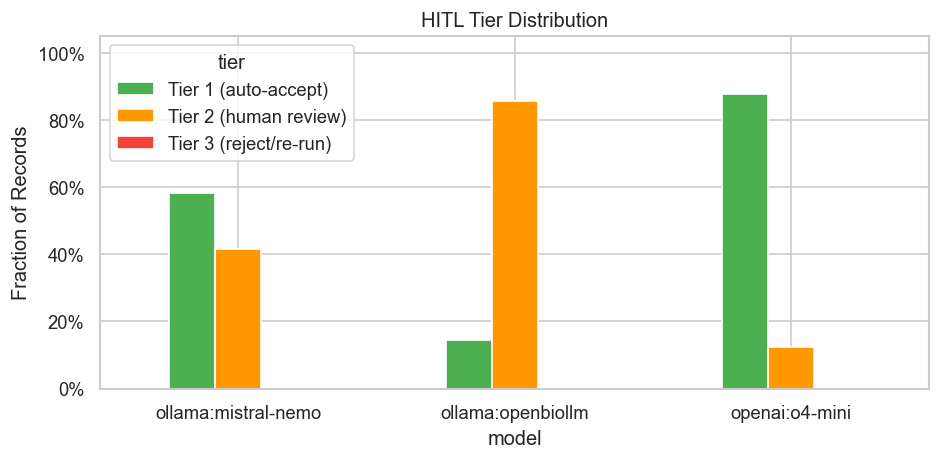

In [166]:
from src.evaluation.hitl_thresholds import TIER_1, TIER_2, TIER_3

tier_data = []
for preds, label in [(preds_o4mini, "openai:o4-mini"), (preds_llama3, "ollama:mistral-nemo"), (preds_openbiollm, "ollama:openbiollm")]:
    if not preds:
        continue
    dist = tier_distribution(preds)
    for tier, frac in dist.items():
        tier_data.append({"model": label, "tier": tier, "fraction": frac})

if tier_data:
    tier_df = pd.DataFrame(tier_data)
    pivot_tier = tier_df.pivot(index="tier", columns="model", values="fraction")
    pivot_tier.index = pivot_tier.index.map({
        TIER_1: "Tier 1 (auto-accept)",
        TIER_2: "Tier 2 (human review)",
        TIER_3: "Tier 3 (reject/re-run)",
    })

    display(
        pivot_tier.style
        .format("{:.1%}")
        .set_caption("HITL Tier Distribution by Model")
    )

    fig, ax = plt.subplots(figsize=(8, 4))
    pivot_tier.T.plot(kind="bar", ax=ax, color=["#4CAF50", "#FF9800", "#F44336"])
    ax.set_ylabel("Fraction of Records")
    ax.set_xticklabels(pivot_tier.columns, rotation=0)
    ax.set_ylim(0, 1.05)
    ax.set_title("HITL Tier Distribution")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    plt.tight_layout()
    plt.show()
else:
    print("No results loaded yet.")

In [167]:
# Per-record tier assignments
from src.evaluation.hitl_thresholds import classify_record

gt_lookup = {r["report_id"]: r for r in ground_truth}

tier_records = []
for preds, label in [(preds_o4mini, "openai:o4-mini"), (preds_llama3, "ollama:mistral-nemo"), (preds_openbiollm, "ollama:openbiollm")]:
    for r in preds:
        rid = r.get("report_id")
        gt  = gt_lookup.get(rid, {})
        gt_tnm = gt.get("tnm_stage") or {}
        pred_tnm = r.get("tnm_stage") or {}
        tier_records.append({
            "model":              label,
            "report_id":          rid,
            "tier":               classify_record(r),
            "validation_status":  r.get("validation_status"),
            "hallucination_flags":len(r.get("hallucination_flags") or []),
            # predictions
            "pred_T":             pred_tnm.get("T"),
            "pred_N":             pred_tnm.get("N"),
            "pred_M":             pred_tnm.get("M"),
            "pred_grade":         r.get("tumor_grade"),
            # ground truth
            "gt_T":               gt_tnm.get("T"),
            "gt_N":               gt_tnm.get("N"),
            "gt_M":               gt_tnm.get("M"),
            "gt_grade":           gt.get("tumor_grade"),
        })

df_tiers = pd.DataFrame(tier_records)
display(df_tiers[df_tiers["hallucination_flags"] > 0].sort_values("hallucination_flags", ascending=False))

,model,report_id,tier,validation_status,hallucination_flags,pred_T,pred_N,pred_M,pred_grade,gt_T,gt_N,gt_M,gt_grade
337,ollama...,TCGA-A...,tier_2,vocab_...,2,pT3 (r...,pN3a (...,pMX,None,pT3,pN3a,pMX,Grade 1
281,ollama...,TCGA-9...,tier_2,vocab_...,2,pT1b,pNO,Not ap...,None,pT1b,pN0,None,Grade ...
332,ollama...,TCGA-B...,tier_2,vocab_...,1,None,None,None,Grade ...,None,None,None,Grade 1
338,ollama...,TCGA-A...,tier_2,vocab_...,1,pT2,pN1a,None,Grade 2/3,pT1c,pN1a,None,Grade 2
339,ollama...,TCGA-A...,tier_2,vocab_...,1,pT1c,pNO(i+),None,Grade 3,pT1c,pN0(i+...,None,Grade 3
347,ollama...,TCGA-J...,tier_2,vocab_...,1,pT1a,pN0,pMX,Grade 3/4,pT1a,pN0,pMX,Grade 3
350,ollama...,TCGA-2...,tier_2,valid,1,None,None,None,None,None,None,None,None
351,ollama...,TCGA-2...,tier_2,valid,1,None,None,None,None,None,None,None,None
352,ollama...,TCGA-6...,tier_2,vocab_...,1,pT2,pN0,cM0,Grade III,T2,None,M0,Grade 3
75,openai...,TCGA-A...,tier_2,vocab_...,1,oT2,N3a,MX,Grade 3,pT2,pN3a,None,Grade 3


## 7. OOV Investigation

Reconstructs the investigation that drove the Phase 6 vocab expansion.
We filter the o4-mini v2 eval results to  records, break down what triggered each flag, and identify which OOV grade values are legitimate clinical terms (and should be added to ) vs. genuinely malformed outputs (and should stay flagged).

In [168]:
from collections import Counter
import re
from src.pipeline.validator import _GRADE_VOCAB as CURRENT_GRADE_VOCAB
from src.pipeline.validator import _normalise_grade

# OLD vocab = what existed before Phase 6 was committed
# (Phase 6 expanded it; v1.3 on this branch added moderately-to-poorly variants)
OLD_GRADE_VOCAB = frozenset({
    "Grade 1", "Grade 2", "Grade 3", "Grade 4",
    "G1", "G2", "G3", "G4", "GX",
    "well differentiated", "moderately differentiated",
    "poorly differentiated", "undifferentiated",
    "low grade", "intermediate grade", "high grade",
})

# Terms added in Phase 6 + branch v1.3
OLD_LOWER = frozenset(g.lower() for g in OLD_GRADE_VOCAB)
def _vocab_generation(term_lower):
    if term_lower in OLD_LOWER:
        return "in old vocab"
    elif term_lower in frozenset(_normalise_grade(g) for g in CURRENT_GRADE_VOCAB):
        return "added Phase 6/v1.3"
    else:
        return "still OOV (non-canonical)"

print("Current _GRADE_VOCAB has", len(CURRENT_GRADE_VOCAB), "terms")
print("Old vocab had", len(OLD_GRADE_VOCAB), "terms")
print("Added terms:")
added = sorted(t for t in CURRENT_GRADE_VOCAB if t not in OLD_GRADE_VOCAB)
for t in added:
    print(f"  {t!r}")

print()
for model_label, preds in [
    ("o4-mini",      preds_o4mini),
    ("mistral-nemo", preds_llama3),
    ("openbiollm",   preds_openbiollm),
]:
    if not preds:
        continue
    flagged      = [r for r in preds if r.get("validation_status") == "vocab_flagged"]
    grade_flags  = [
        flag for r in flagged
        for flag in (r.get("hallucination_flags") or [])
        if flag.startswith("unrecognised_grade")
    ]
    oov_terms    = [f.split(": ", 1)[1].strip("'\"") for f in grade_flags]
    oov_counts   = Counter(oov_terms)

    rows = []
    for term, count in oov_counts.most_common():
        norm  = _normalise_grade(term)
        gen   = _vocab_generation(norm)
        rows.append({"model_output": term, "normalised": norm, "count": count, "vocab_status": gen})

    oov_df = pd.DataFrame(rows) if rows else pd.DataFrame(columns=["model_output", "normalised", "count", "vocab_status"])
    print(f"{'─'*60}")
    print(f"Model: {model_label}   |   vocab_flagged records: {len(flagged)}   |   grade flags: {len(grade_flags)}")
    if oov_df.empty:
        print("  No OOV grade values.")
    else:
        display(oov_df.style
            .set_caption(f"Grade OOV analysis — {model_label}")
            .apply(lambda col: [
                "background-color: #c8e6c9" if v == "in old vocab" else
                "background-color: #fff9c4" if v == "added Phase 6/v1.3" else
                "background-color: #ffcdd2"
                for v in col
            ], subset=["vocab_status"]))


Current _GRADE_VOCAB has 28 terms
Old vocab had 16 terms
Added terms:
  'Grade 1-2'
  'Grade 2-3'
  'Grade 3-4'
  'High'
  'Intermediate'
  'Low'
  'NHG1'
  'NHG2'
  'NHG3'
  'moderate to poorly differentiated'
  'moderately to poorly differentiated'
  'poorly to moderately differentiated'

────────────────────────────────────────────────────────────
Model: o4-mini   |   vocab_flagged records: 1   |   grade flags: 0
  No OOV grade values.
────────────────────────────────────────────────────────────
Model: mistral-nemo   |   vocab_flagged records: 26   |   grade flags: 15


,model_output,normalised,count,vocab_status
0,Grade II,grade 2,2,in old vocab
1,Grade 2 (moderately differentiated),grade 2 (moderately differentiated),2,still OOV (non-canonical)
2,Grade II of III,grade 2 of 3,1,still OOV (non-canonical)
3,Grade 2/4,grade 2/4,1,still OOV (non-canonical)
4,well-differentiated,well-differentiated,1,still OOV (non-canonical)
5,Grade 3 (poorly differentiated),grade 3 (poorly differentiated),1,still OOV (non-canonical)
6,Grade 2/3 (moderately differentiated),grade 2/3 (moderately differentiated),1,still OOV (non-canonical)
7,Grade II-III/III,grade 2-3/3,1,still OOV (non-canonical)
8,Grade 1 (good nuclear grade),grade 1 (good nuclear grade),1,still OOV (non-canonical)
9,Grade 2/3,grade 2/3,1,still OOV (non-canonical)


────────────────────────────────────────────────────────────
Model: openbiollm   |   vocab_flagged records: 7   |   grade flags: 4


,model_output,normalised,count,vocab_status
0,Grade 2 (of III),grade 2 (of 3),1,still OOV (non-canonical)
1,Grade II (of III),grade 2 (of 3),1,still OOV (non-canonical)
2,Grade 2 (of 3) - Nottingham grade II,grade 2 (of 3) - nottingham grade 2,1,still OOV (non-canonical)
3,Grade 3 (intermediate nuclear grade),grade 3 (intermediate nuclear grade),1,still OOV (non-canonical)


In [169]:
import re
from src.pipeline.validator import _TNM_T, _TNM_N, _TNM_M

# TNM regex patterns used by the validator (v1.3):
# T: ^(p|c|y|r|a)?T([0-4][a-c]?|X|is)(\([^)]+\))?$
# N: ^(p|c|y|r)?N([0-3][a-c]?|X)(mi)?(\s*\([^)]+\))*$
# M: ^(p|c)?M([01][a-c]?|X)$

TNM_REGEXES = {"T": _TNM_T, "N": _TNM_N, "M": _TNM_M}

for model_label, preds in [
    ("o4-mini",      preds_o4mini),
    ("mistral-nemo", preds_llama3),
    ("openbiollm",   preds_openbiollm),
]:
    if not preds:
        continue

    print(f"{'─'*60}")
    print(f"Model: {model_label}   (n={len(preds)} records)")
    found_any = False

    for sub, regex in TNM_REGEXES.items():
        field = f"tnm_stage.{sub}"
        invalid_vals = Counter()
        for r in preds:
            val = get_field_value(r, field)
            if val and not regex.match(val):
                invalid_vals[val] += 1

        if not invalid_vals:
            print(f"  tnm_stage.{sub}: no invalid values")
            continue

        found_any = True
        rows = []
        for val, count in invalid_vals.most_common():
            # Try to infer why it fails
            reasons = []
            if not val.upper().startswith(sub):
                reasons.append(f"missing {sub} prefix")
            if " " in val.strip():
                reasons.append("contains space (may need stripping)")
            if not reasons:
                reasons.append("pattern mismatch — check prefix/suffix")
            rows.append({"invalid_value": val, "count": count, "likely_issue": "; ".join(reasons)})

        inv_df = pd.DataFrame(rows)
        display(inv_df.style
            .set_caption(f"Invalid tnm_stage.{sub} values — {model_label}")
            .background_gradient(subset=["count"], cmap="Reds", vmin=0))

    if not found_any:
        print("  All TNM values pass the validator regex (or are null).")


────────────────────────────────────────────────────────────
Model: o4-mini   (n=180 records)


,invalid_value,count,likely_issue
0,oT2,1,missing T prefix


  tnm_stage.N: no invalid values
  tnm_stage.M: no invalid values
────────────────────────────────────────────────────────────
Model: mistral-nemo   (n=180 records)


,invalid_value,count,likely_issue
0,pT3 (right) pT1 (left),1,missing T prefix; contains space (may need stripping)


,invalid_value,count,likely_issue
0,pNO,4,missing N prefix
1,pNO(i-),2,missing N prefix
2,pNO(i+),2,missing N prefix
3,pNO(sn),1,missing N prefix
4,"pN3a (right), pN0 (left)",1,missing N prefix; contains space (may need stripping)


,invalid_value,count,likely_issue
0,Not applicable,2,missing M prefix; contains space (may need stripping)


────────────────────────────────────────────────────────────
Model: openbiollm   (n=180 records)


,invalid_value,count,likely_issue
0,pTlc (m),1,missing T prefix; contains space (may need stripping)


,invalid_value,count,likely_issue
0,pNO (i+),1,missing N prefix; contains space (may need stripping)


,invalid_value,count,likely_issue
0,L1 V1,1,missing M prefix; contains space (may need stripping)


# §7 Summary — OOV triage

| Model | vocab_flagged records | grade OOV flags | TNM flags |
|-------|----------------------|-----------------|-----------|
| *run cells 22-23 above to fill in* | | | |

**Decision log:**
- Green  = term was already in the old vocab (pre-Phase 6) — flags reflect a pre-existing validator gap  
- Yellow = term added to vocab in Phase 6 / v1.3 — legitimate clinical variant now accepted  
- Red    = still OOV — non-canonical output, model should be penalised  


## 8. Prediction Distribution Analysis

Complements the per-field metrics above by showing *what* the models are predicting: value frequencies, distribution shapes vs. ground truth, and how much of each model's predicted vocabulary falls outside the GT vocabulary (OOV rate).

Subsections:
- **8.1** Value frequency per field (unique counts + top-N tables)
- **8.2** Distribution comparison charts (GT vs models, side-by-side)
- **8.3** Vocabulary coverage summary (OOV rate per field × model)

In [170]:
from src.evaluation.metrics import get_field_value


def extract_values(records: list[dict], field: str) -> list[str]:
    """Extract all values for a field across records; None becomes '(null)'."""
    return [get_field_value(r, field) or "(null)" for r in records]


MODELS = {
    "GT": ground_truth,
    "o4-mini": preds_o4mini,
    "mistral-nemo": preds_llama3,
    "openbiollm": preds_openbiollm,
}

### 8.1 Value Frequency per Field

In [171]:
# Unique value counts per field across GT and both models
unique_rows = []
for field in ALL_FIELDS:
    row = {"field": field}
    for label, records in MODELS.items():
        vals = extract_values(records, field)
        row[f"{label} unique"] = len(set(vals))
    unique_rows.append(row)

unique_df = pd.DataFrame(unique_rows).set_index("field")
display(
    unique_df.style
    .background_gradient(cmap="Blues")
    .set_caption("Unique value count per field (including '(null)' as a value)")
)

,GT unique,o4-mini unique,mistral-nemo unique,openbiollm unique
field,,,,
primary_site,76,62,82,23
specimen_type,82,51,88,17
histological_diagnosis,18,22,52,5
histological_subtype,43,39,41,7
tumor_grade,32,8,22,9
tnm_stage.T,16,16,13,7
tnm_stage.N,19,17,30,11
tnm_stage.M,9,9,6,6


In [172]:
TOP_N = 12

for field in ALL_FIELDS:
    gt_counts = pd.Series(extract_values(ground_truth, field)).value_counts()
    o4_counts = pd.Series(extract_values(preds_o4mini, field)).value_counts()
    ll_counts = pd.Series(extract_values(preds_llama3, field)).value_counts()
    ob_counts = pd.Series(extract_values(preds_openbiollm, field)).value_counts()

    top_vals = gt_counts.head(TOP_N).index.tolist()
    freq_df = pd.DataFrame(
        {
            "GT":           [gt_counts.get(v, 0) for v in top_vals],
            "o4-mini":      [o4_counts.get(v, 0) for v in top_vals],
            "mistral-nemo": [ll_counts.get(v, 0) for v in top_vals],
            "openbiollm":   [ob_counts.get(v, 0) for v in top_vals],
        },
        index=top_vals,
    )
    freq_df.index.name = "value"
    display(
        freq_df.style
        .background_gradient(subset=["GT"],           cmap="Blues",   vmin=0)
        .background_gradient(subset=["o4-mini"],      cmap="Oranges", vmin=0)
        .background_gradient(subset=["mistral-nemo"], cmap="Greens",  vmin=0)
        .background_gradient(subset=["openbiollm"],   cmap="Purples", vmin=0)
        .set_caption(f"Top-{TOP_N} values by GT frequency — {field}")
    )


,GT,o4-mini,mistral-nemo,openbiollm
value,,,,
left breast,20,20,21,2
right breast,19,20,16,1
"right lung, upper lobe",18,20,8,1
"left lung, upper lobe",13,17,10,0
"right lung, lower lobe",10,11,9,2
"left lung, lower lobe",8,9,2,0
"left breast, upper outer quadrant",6,6,7,7
breast (laterality not stated),5,0,0,0
"right breast, lower outer quadrant",5,5,6,1


,GT,o4-mini,mistral-nemo,openbiollm
value,,,,
lobectomy (right upper lobe),16,0,9,2
lobectomy (left upper lobe),15,2,7,3
modified radical mastectomy,9,11,5,1
lobectomy (left lower lobe),8,0,1,0
(null),8,8,4,146
lobectomy (right lower lobe),7,2,4,4
radical mastectomy,6,7,6,13
mastectomy,6,12,15,1
pneumonectomy (left),5,0,0,0


,GT,o4-mini,mistral-nemo,openbiollm
value,,,,
invasive ductal carcinoma,40,43,34,0
adenocarcinoma,40,39,27,4
squamous cell carcinoma,39,33,22,7
infiltrating ductal carcinoma,24,23,23,21
invasive lobular carcinoma,14,15,7,0
infiltrative ductal carcinoma,6,4,6,0
infiltrating lobular carcinoma,3,2,6,2
invasive adenocarcinoma,3,3,0,0
(null),2,3,2,146


,GT,o4-mini,mistral-nemo,openbiollm
value,,,,
NST,65,64,64,14
(null),55,73,56,161
lobular,13,0,2,0
lobular pleomorphic,4,0,8,0
basaloid,4,4,1,1
papillary,2,2,0,0
"lepidic predominant, mixed (60% lepidic, 40% acinar)",1,0,0,0
mixed with focal papillary and focal solid components,1,0,0,0
"invasive adenocarcinoma, in part clear-cell type",1,0,0,0


,GT,o4-mini,mistral-nemo,openbiollm
value,,,,
Grade 2,45,59,55,5
Grade 3,31,40,40,19
Grade 2 (moderately differentiated),26,0,2,0
Grade 3 (poorly differentiated),21,0,1,0
(null),14,19,53,149
Grade 1,11,11,11,0
Grade 1 (well differentiated),5,0,0,0
Grade 2–3 (moderately to poorly differentiated),2,0,0,0
Grade 4,2,1,2,2


,GT,o4-mini,mistral-nemo,openbiollm
value,,,,
pT2,70,78,82,28
pT1c,23,25,15,0
pT3,22,20,13,1
(null),15,16,35,147
pT1b,10,10,10,0
pT2b,8,3,3,1
pT2a,7,7,5,0
pT1a,6,6,6,0
T2,4,1,0,0


,GT,o4-mini,mistral-nemo,openbiollm
value,,,,
pN0,71,77,58,19
pN1,22,27,16,5
(null),21,21,46,147
pN1a,12,10,9,0
pN2,9,12,4,1
pN2a,9,5,5,0
pN3a,8,7,6,0
pN0(sn),6,2,0,0
N0,4,2,0,0


,GT,o4-mini,mistral-nemo,openbiollm
value,,,,
(null),111,94,120,168
pMX,54,62,51,7
M0,5,1,0,0
pM0,2,5,0,2
MX,2,2,5,1
M1,2,1,0,0
pMx,2,12,0,0
pM1,1,1,1,0
cM0,1,2,1,0


In [173]:
TNM_FIELDS = ["tnm_stage.T", "tnm_stage.N", "tnm_stage.M"]

for field in TNM_FIELDS:
    gt_counts = pd.Series(extract_values(ground_truth, field)).value_counts()
    o4_counts = pd.Series(extract_values(preds_o4mini, field)).value_counts()
    ll_counts = pd.Series(extract_values(preds_llama3, field)).value_counts()
    ob_counts = pd.Series(extract_values(preds_openbiollm, field)).value_counts()

    all_vals = gt_counts.index.tolist()
    freq_df = pd.DataFrame(
        {
            "GT":           [gt_counts.get(v, 0) for v in all_vals],
            "o4-mini":      [o4_counts.get(v, 0) for v in all_vals],
            "mistral-nemo": [ll_counts.get(v, 0) for v in all_vals],
            "openbiollm":   [ob_counts.get(v, 0) for v in all_vals],
        },
        index=all_vals,
    )
    freq_df.index.name = "value"
    display(
        freq_df.style
        .background_gradient(subset=["GT"],           cmap="Blues",   vmin=0)
        .background_gradient(subset=["o4-mini"],      cmap="Oranges", vmin=0)
        .background_gradient(subset=["mistral-nemo"], cmap="Greens",  vmin=0)
        .background_gradient(subset=["openbiollm"],   cmap="Purples", vmin=0)
        .set_caption(f"All values by GT frequency — {field}")
    )


,GT,o4-mini,mistral-nemo,openbiollm
value,,,,
pT2,70,78,82,28
pT1c,23,25,15,0
pT3,22,20,13,1
(null),15,16,35,147
pT1b,10,10,10,0
pT2b,8,3,3,1
pT2a,7,7,5,0
pT1a,6,6,6,0
T2,4,1,0,0


,GT,o4-mini,mistral-nemo,openbiollm
value,,,,
pN0,71,77,58,19
pN1,22,27,16,5
(null),21,21,46,147
pN1a,12,10,9,0
pN2,9,12,4,1
pN2a,9,5,5,0
pN3a,8,7,6,0
pN0(sn),6,2,0,0
N0,4,2,0,0


,GT,o4-mini,mistral-nemo,openbiollm
value,,,,
(null),111,94,120,168
pMX,54,62,51,7
M0,5,1,0,0
pM0,2,5,0,2
MX,2,2,5,1
M1,2,1,0,0
pMx,2,12,0,0
pM1,1,1,1,0
cM0,1,2,1,0


### 8.2 Distribution Comparison Charts

Horizontal grouped bar charts showing the top values by GT frequency for each field. GT counts are sorted descending; model bars show how often they predicted the same values.

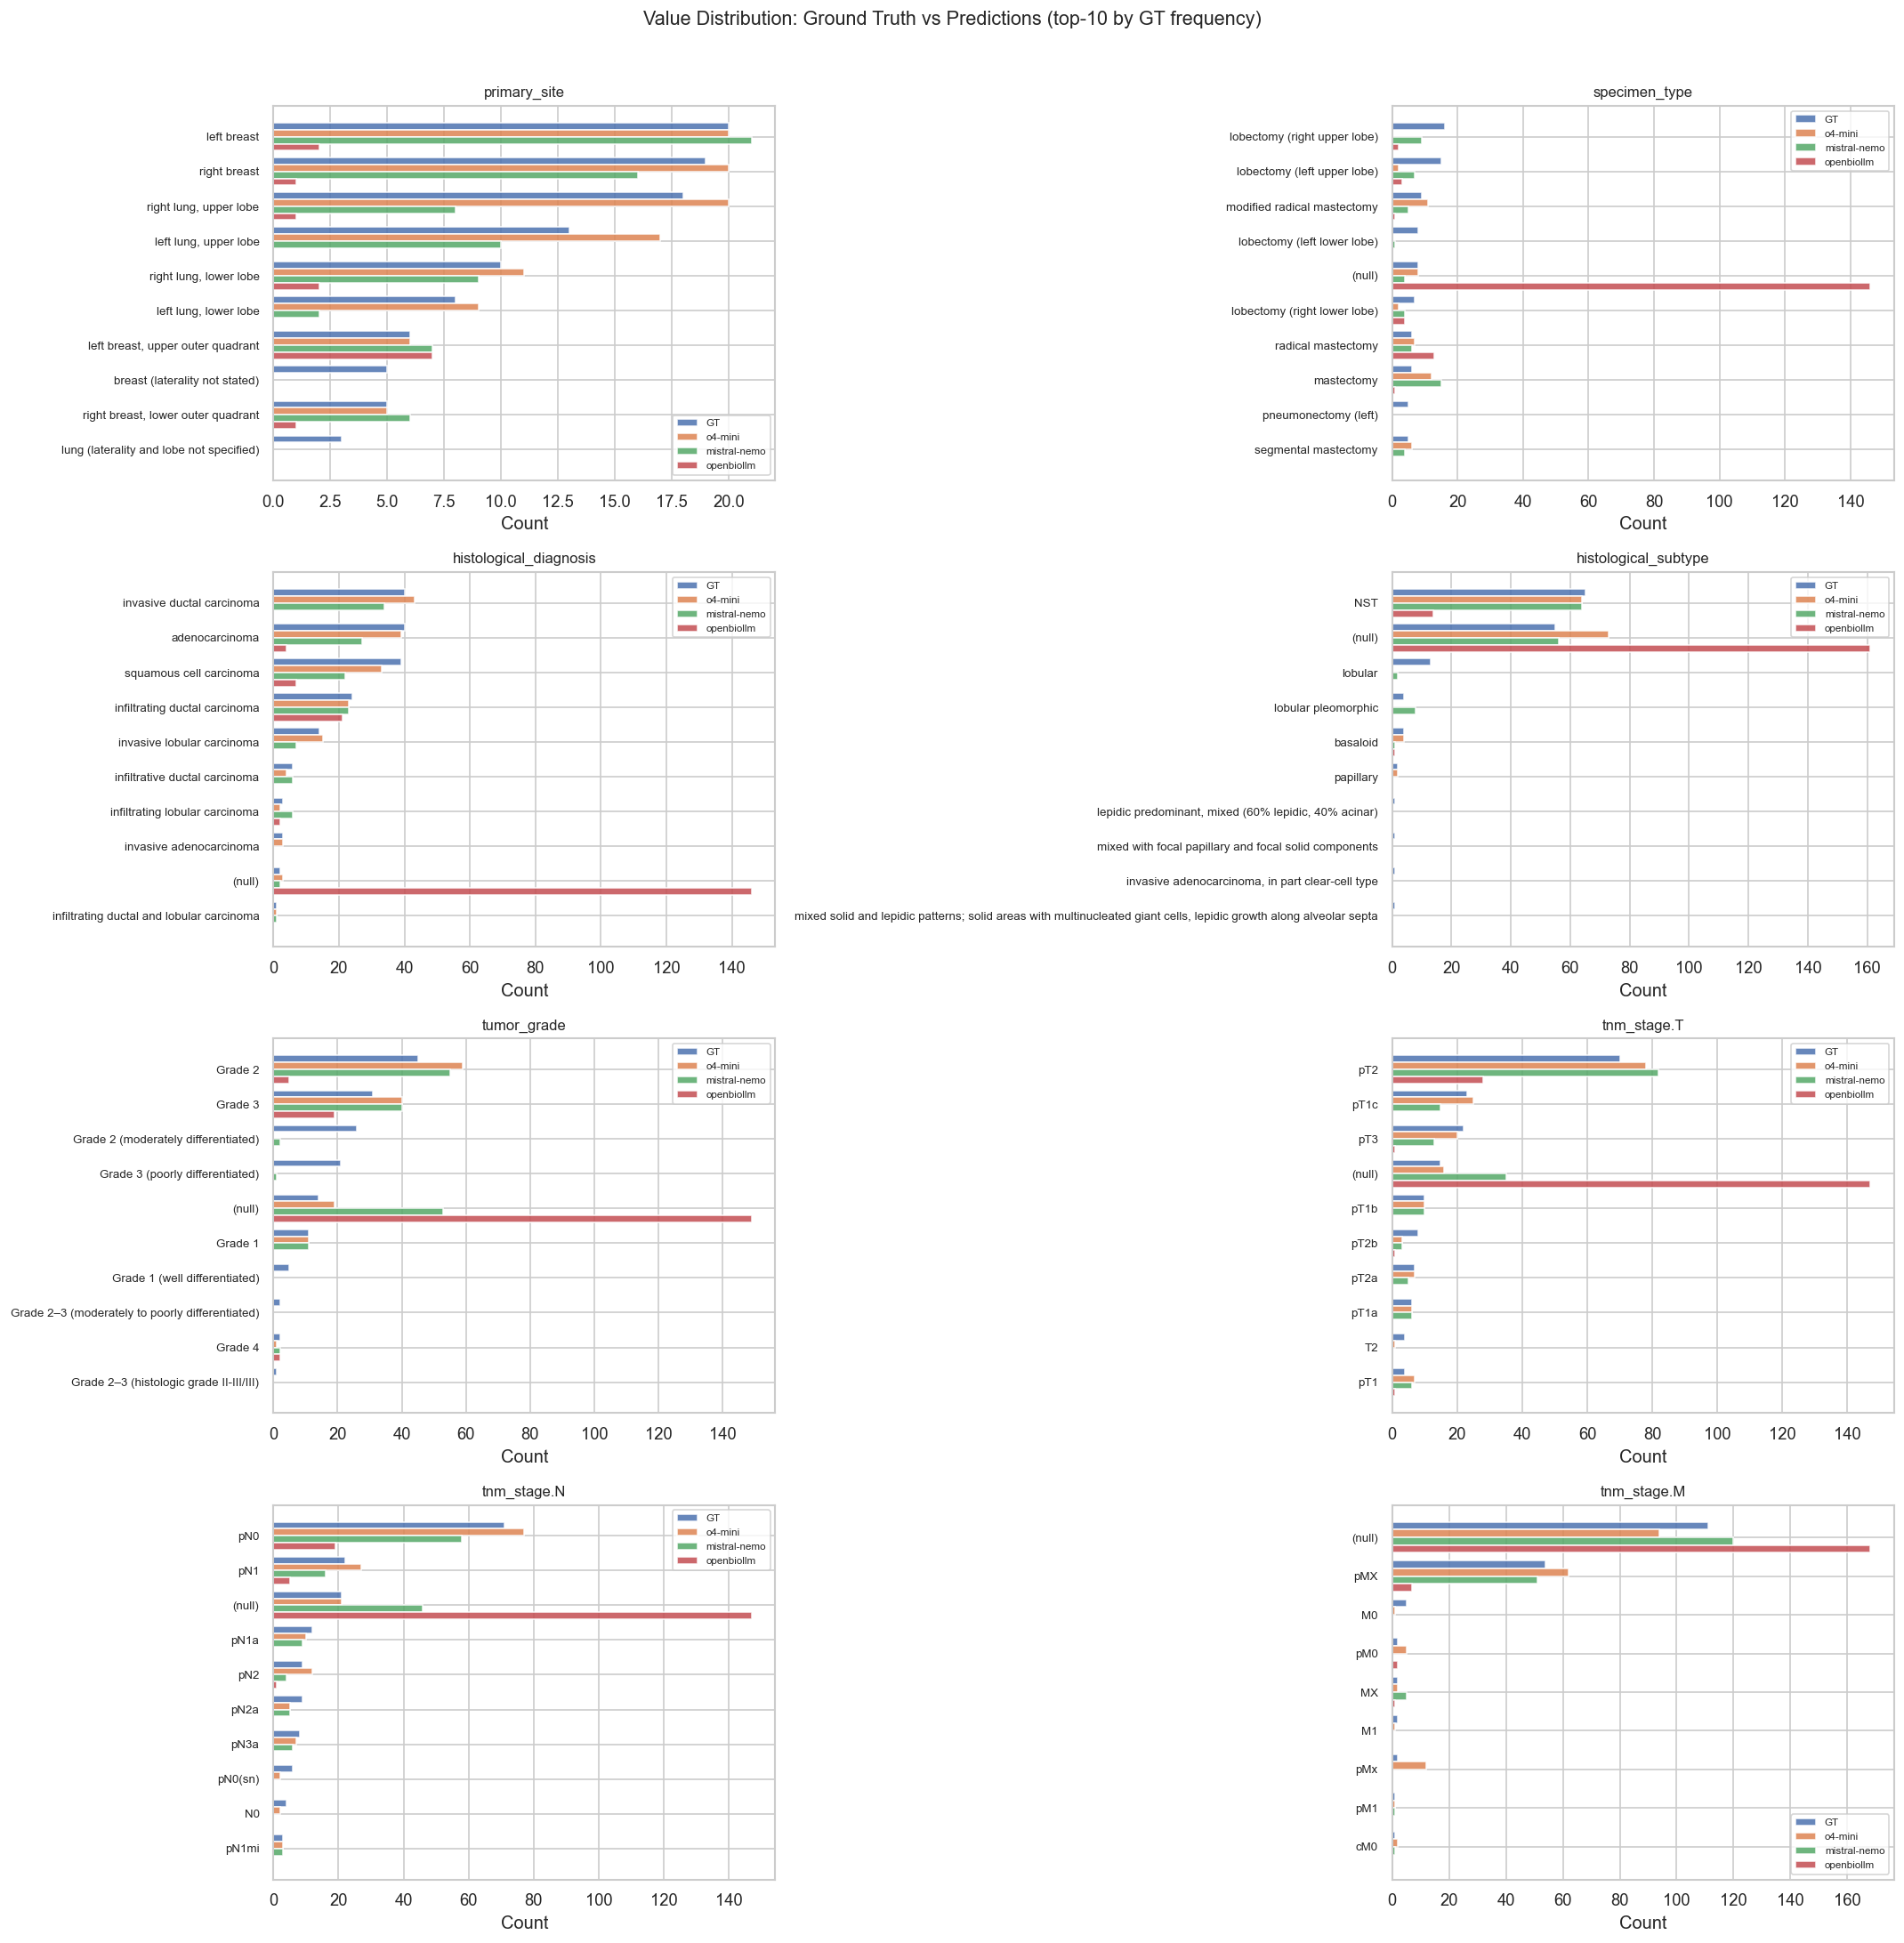

In [174]:
from math import ceil

CHART_TOP_K = 10
MODEL_COLORS = {"GT": "#4C72B0", "o4-mini": "#DD8452", "mistral-nemo": "#55A868", "openbiollm": "#C44E52"}

n_cols = 2
n_rows = ceil(len(ALL_FIELDS) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4.5))
axes = axes.flatten()

for i, field in enumerate(ALL_FIELDS):
    ax = axes[i]
    gt_counts = pd.Series(extract_values(ground_truth, field)).value_counts().head(CHART_TOP_K)
    top_vals  = gt_counts.index.tolist()

    bar_h    = 0.20
    y        = range(len(top_vals))
    model_list = list(MODELS.items())
    n_models   = len(model_list)

    for j, (label, records) in enumerate(model_list):
        counts  = pd.Series(extract_values(records, field)).value_counts()
        vals    = [counts.get(v, 0) for v in top_vals]
        offsets = [yi + (j - (n_models - 1) / 2) * bar_h for yi in y]
        ax.barh(offsets, vals, bar_h, label=label, color=MODEL_COLORS[label], alpha=0.85)

    ax.set_yticks(list(y))
    ax.set_yticklabels(top_vals, fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel("Count")
    ax.set_title(field, fontsize=10)
    ax.legend(fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    f"Value Distribution: Ground Truth vs Predictions (top-{CHART_TOP_K} by GT frequency)",
    y=1.01, fontsize=13,
)
plt.tight_layout()
plt.show()


### 8.3 Vocabulary Coverage

For each field and model: how many of the distinct predicted values (excluding nulls) appear in the GT vocabulary? A low `vocab_coverage_%` means the model is generating values outside the annotated label set — OOV hallucinations. Compare with the OOV investigation in Section 7.

In [175]:
coverage_rows = []
for field in ALL_FIELDS:
    gt_vocab = set(extract_values(ground_truth, field)) - {"(null)"}
    for model_label, records in [
        ("o4-mini",      preds_o4mini),
        ("mistral-nemo", preds_llama3),
        ("openbiollm",   preds_openbiollm),
    ]:
        pred_vals = set(extract_values(records, field)) - {"(null)"}
        n_unique  = len(pred_vals)
        n_in_gt   = len(pred_vals & gt_vocab)
        n_oov     = n_unique - n_in_gt
        coverage_rows.append({
            "field":            field,
            "model":            model_label,
            "n_unique_pred":    n_unique,
            "n_in_gt_vocab":    n_in_gt,
            "vocab_coverage_%": round(100 * n_in_gt / n_unique, 1) if n_unique else 100.0,
            "oov_rate_%":       round(100 * n_oov  / n_unique, 1) if n_unique else 0.0,
        })

coverage_df = pd.DataFrame(coverage_rows).set_index(["field", "model"])
display(
    coverage_df.style
    .background_gradient(subset=["vocab_coverage_%"], cmap="RdYlGn",   vmin=0, vmax=100)
    .background_gradient(subset=["oov_rate_%"],       cmap="RdYlGn_r", vmin=0, vmax=100)
    .format({"vocab_coverage_%": "{:.1f}%", "oov_rate_%": "{:.1f}%"})
    .set_caption("Vocabulary coverage: fraction of model-predicted values (non-null) that appear in the GT vocabulary")
)


### 8.4 Similarity-Complete Heatmap

Quick overview of `mean_similarity_complete` per semantic field × model. Unlike `mean_similarity` (which only averages co-present pairs), `sim_complete` penalises omissions and hallucinations — so it's the fairer comparison. This heatmap answers: *which field/model combination is most problematic?*

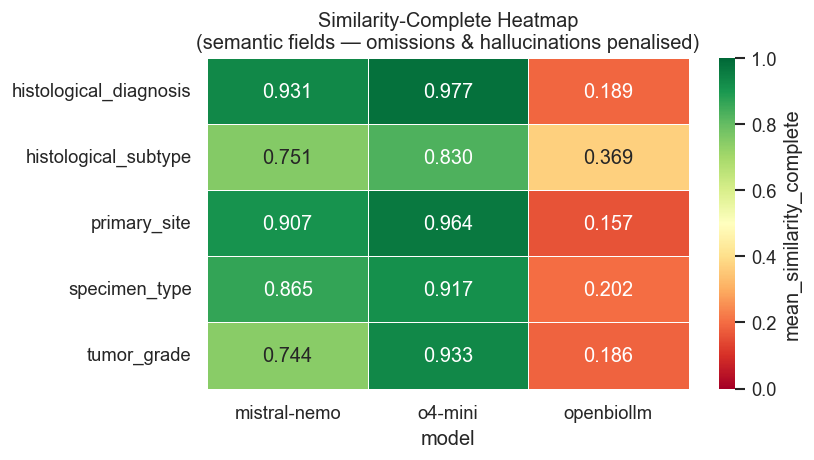

In [176]:
heatmap_rows = []
for model_label, preds in [
    ("o4-mini",      preds_o4mini),
    ("mistral-nemo", preds_llama3),
    ("openbiollm",   preds_openbiollm),
]:
    if not preds:
        continue
    for sm in compute_semantic_metrics(preds, ground_truth):
        heatmap_rows.append({
            "field":        sm.field,
            "model":        model_label,
            "sim_complete": round(sm.mean_similarity_complete, 3),
        })

heatmap_df = pd.DataFrame(heatmap_rows).pivot(index="field", columns="model", values="sim_complete")

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(
    heatmap_df, annot=True, fmt=".3f", cmap="RdYlGn", vmin=0, vmax=1,
    linewidths=0.5, ax=ax, cbar_kws={"label": "mean_similarity_complete"},
)
ax.set_title("Similarity-Complete Heatmap\n(semantic fields — omissions & hallucinations penalised)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


### 8.5 Per-Record Score Distributions

Box plots over all 180 records. **Semantic fields** use `sim_complete` (continuous 0–1, includes null penalisation). **TNM fields** use `exact_match` (binary 0/1 — so boxes will be bimodal). Same scale across all fields makes models directly comparable field-by-field.

/var/folders/8r/mwfqwtnd0xd7wgh0rvjzfkv00000gn/T/ipykernel_30339/199463404.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/8r/mwfqwtnd0xd7wgh0rvjzfkv00000gn/T/ipykernel_30339/199463404.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["o4", "mist", "obio"], fontsize=6)
/var/folders/8r/mwfqwtnd0xd7wgh0rvjzfkv00000gn/T/ipykernel_30339/199463404.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/8r/mwfqwtnd0xd7wgh0rvjzfkv00000gn/T/ipykernel_30339/199463404.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after 

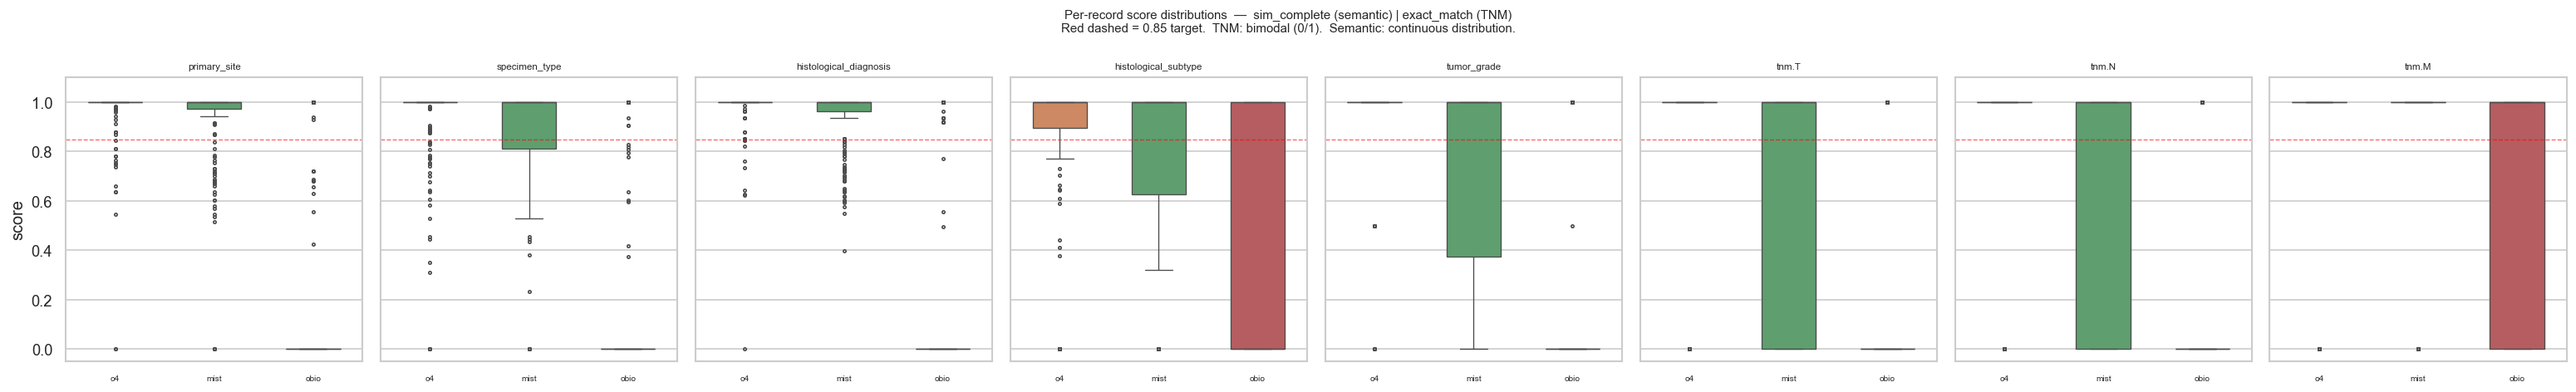

In [177]:
from src.evaluation.metrics import get_field_value
from src.evaluation.semantic import semantic_score as _sem_score


def _all_field_scores(preds, golds):
    pred_map   = {r["report_id"]: r for r in preds}
    tnm_fields = [f for f in ALL_FIELDS if f not in SEMANTIC_FIELDS]
    rows = []
    for g in golds:
        p, row = pred_map.get(g["report_id"], {}), {}
        for f in SEMANTIC_FIELDS:
            pv, gv = get_field_value(p, f), get_field_value(g, f)
            if pv is None and gv is None:
                row[f] = 1.0
            elif gv is not None and pv is None:
                row[f] = 0.0
            elif gv is None and pv is not None:
                row[f] = 0.0
            else:
                s = _sem_score(pv, gv, f)
                row[f] = s if s is not None else 0.0
        for f in tnm_fields:
            pv = (get_field_value(p, f) or "").strip().lower()
            gv = (get_field_value(g, f) or "").strip().lower()
            row[f] = 1.0 if pv == gv else 0.0
        rows.append(row)
    return pd.DataFrame(rows)


box_data = []
for model_label, preds in [
    ("o4-mini",      preds_o4mini),
    ("mistral-nemo", preds_llama3),
    ("openbiollm",   preds_openbiollm),
]:
    if not preds:
        continue
    scores_df = _all_field_scores(preds, ground_truth)
    for f in ALL_FIELDS:
        for s in scores_df[f]:
            box_data.append({"field": f, "model": model_label, "score": s})

box_df = pd.DataFrame(box_data)
MODEL_PALETTE = ["#DD8452", "#55A868", "#C44E52"]

fig, axes = plt.subplots(1, len(ALL_FIELDS), figsize=(26, 4), sharey=True)
for ax, field in zip(axes, ALL_FIELDS):
    sub = box_df[box_df["field"] == field]
    sns.boxplot(
        data=sub, x="model", y="score", ax=ax,
        palette=MODEL_PALETTE, width=0.55, linewidth=0.8, fliersize=2,
    )
    ax.set_title(field.replace("tnm_stage.", "tnm."), fontsize=7)
    ax.set_xlabel("")
    ax.set_ylim(-0.05, 1.10)
    ax.axhline(0.85, color="red", linestyle="--", linewidth=0.8, alpha=0.6)
    ax.set_xticklabels(["o4", "mist", "obio"], fontsize=6)

axes[0].set_ylabel("score")
plt.suptitle(
    "Per-record score distributions  —  sim_complete (semantic) | exact_match (TNM)\n"
    "Red dashed = 0.85 target.  TNM: bimodal (0/1).  Semantic: continuous distribution.",
    fontsize=9,
)
plt.tight_layout()
plt.show()


### 8.6 Error-Type Breakdown

Per field × model, every record is classified into one of six types. Designed for clinical review — readable without statistics background.

| Category | Meaning |
|---|---|
| **Exact** | Exact string match after normalisation, or correct absence (both null) |
| **Near-miss** | sim ≥ 0.85 but not exact — same concept, different wording |
| **Partial** | 0.5 ≤ sim < 0.85 — related but not equivalent |
| **Wrong** | sim < 0.5, or wrong TNM string |
| **Omission** | Gold present, prediction absent |
| **Hallucination** | Gold absent, prediction present |

In [178]:
from src.evaluation.metrics import get_field_value
from src.evaluation.semantic import semantic_score as _sem_score

NEAR_MISS_THR = 0.85
PARTIAL_THR   = 0.50


def _error_breakdown(preds, golds, model_label):
    """Classify every record for every field into one of six error types."""
    pred_map = {r["report_id"]: r for r in preds}
    rows = []
    for field in ALL_FIELDS:
        counts = {k: 0 for k in ("Exact", "Near-miss", "Partial", "Wrong", "Omission", "Hallucination")}
        for g in golds:
            p  = pred_map.get(g["report_id"], {})
            pv = get_field_value(p, field)
            gv = get_field_value(g, field)

            if gv is None and pv is None:
                counts["Exact"] += 1                     # correct absence
            elif gv is not None and pv is None:
                counts["Omission"] += 1
            elif gv is None and pv is not None:
                counts["Hallucination"] += 1
            elif field in SEMANTIC_FIELDS:
                s = _sem_score(pv, gv, field)
                if s >= 1.0:
                    counts["Exact"] += 1
                elif s >= NEAR_MISS_THR:
                    counts["Near-miss"] += 1
                elif s >= PARTIAL_THR:
                    counts["Partial"] += 1
                else:
                    counts["Wrong"] += 1
            else:                                        # TNM — exact string match
                if (pv or "").strip().lower() == (gv or "").strip().lower():
                    counts["Exact"] += 1
                else:
                    counts["Wrong"] += 1

        rows.append({"field": field, "model": model_label, **counts})
    return pd.DataFrame(rows)


eb_o4  = _error_breakdown(preds_o4mini,     ground_truth, "o4-mini")
eb_ll  = _error_breakdown(preds_llama3,     ground_truth, "mistral-nemo")
eb_ob  = _error_breakdown(preds_openbiollm, ground_truth, "openbiollm")
eb_all = pd.concat([eb_o4, eb_ll, eb_ob], ignore_index=True).set_index(["field", "model"])

display(
    eb_all.style
    .background_gradient(subset=["Exact"],         cmap="Greens",  vmin=0, vmax=180)
    .background_gradient(subset=["Near-miss"],     cmap="YlGn",    vmin=0, vmax=60)
    .background_gradient(subset=["Partial"],       cmap="YlOrBr",  vmin=0, vmax=60)
    .background_gradient(subset=["Wrong"],         cmap="Reds",    vmin=0, vmax=60)
    .background_gradient(subset=["Omission"],      cmap="Oranges", vmin=0, vmax=60)
    .background_gradient(subset=["Hallucination"], cmap="Purples", vmin=0, vmax=30)
    .set_caption(
        f"Error-type breakdown (n=180 records per field/model). "
        f"Near-miss: sim ≥ {NEAR_MISS_THR}  ·  Partial: {PARTIAL_THR}–{NEAR_MISS_THR}  ·  "
        f"Wrong: < {PARTIAL_THR}. TNM fields use exact-string matching."
    )
)

,,Exact,Near-miss,Partial,Wrong,Omission,Hallucination
field,model,,,,,,
primary_site,o4-mini,147,18,13,2,0,0
specimen_type,o4-mini,138,12,20,4,3,3
histological_diagnosis,o4-mini,158,13,8,0,1,0
histological_subtype,o4-mini,127,13,13,3,21,3
tumor_grade,o4-mini,163,0,10,2,5,0
tnm_stage.T,o4-mini,146,0,0,23,6,5
tnm_stage.N,o4-mini,155,0,0,21,2,2
tnm_stage.M,o4-mini,156,0,0,5,1,18
primary_site,mistral-nemo,108,37,29,5,0,1


## 9. Semantic Similarity (Feature 8)

Exact match punishes the model for being right in different words (`invasive ductal carcinoma` vs `infiltrating ductal carcinoma`). This section reports a **continuous, threshold-free** semantic score alongside exact match — never replacing it.

Per pred/gold pair (both non-null): exact match after normalization → 1.0; `tumor_grade` via deterministic ordinal parser → 1.0/0.0 (embeddings deliberately not used — adjacent grades embed too close); `primary_site` laterality conflict → 0.0 hard rule; otherwise SapBERT cosine similarity (`cambridgeltl/SapBERT-from-PubMedBERT-fulltext`, PubMedBERT fine-tuned on UMLS synonym pairs). Null mismatches stay in the exact-match FN/FP accounting and are excluded here.

Spec: `specs/features/semantic-similarity-eval/`.

In [179]:
from src.evaluation.metrics import SEMANTIC_FIELDS, compute_field_metrics, compute_semantic_metrics
from src.evaluation.semantic import EMBEDDING_MODEL, SEMANTIC_VERSION, semantic_score

print(f"Embedding model: {EMBEDDING_MODEL}  (semantic {SEMANTIC_VERSION})")

sem_rows = []
for model_label, records in [("o4-mini", preds_o4mini), ("mistral-nemo", preds_llama3), ("openbiollm", preds_openbiollm)]:
    if not records:
        continue
    for sm in compute_semantic_metrics(records, ground_truth):
        fm = compute_field_metrics(records, ground_truth, sm.field)
        sem_rows.append({
            "field": sm.field,
            "model": model_label,
            "exact_f1": round(fm.f1, 3),
            "mean_similarity": round(sm.mean_similarity, 3),
            "n_scored_pairs": sm.n_scored_pairs,
        })

sem_df = pd.DataFrame(sem_rows)
display(
    sem_df.pivot(index="field", columns="model", values=["exact_f1", "mean_similarity", "n_scored_pairs"])
    .style.format(precision=3)
    .set_caption("Exact-match F1 vs mean semantic similarity (non-null pairs only)")
)

Embedding model: cambridgeltl/SapBERT-from-PubMedBERT-fulltext  (semantic v1.2)


### 9.1 Score Distributions

Per-field histograms of pair scores. Mass near 1.0 means the model mostly agrees with the gold standard (exactly or in equivalent words); a left tail shows genuine disagreements. A suspiciously uniform spread would suggest the embedding is not separating same-concept from different-concept pairs for that field.

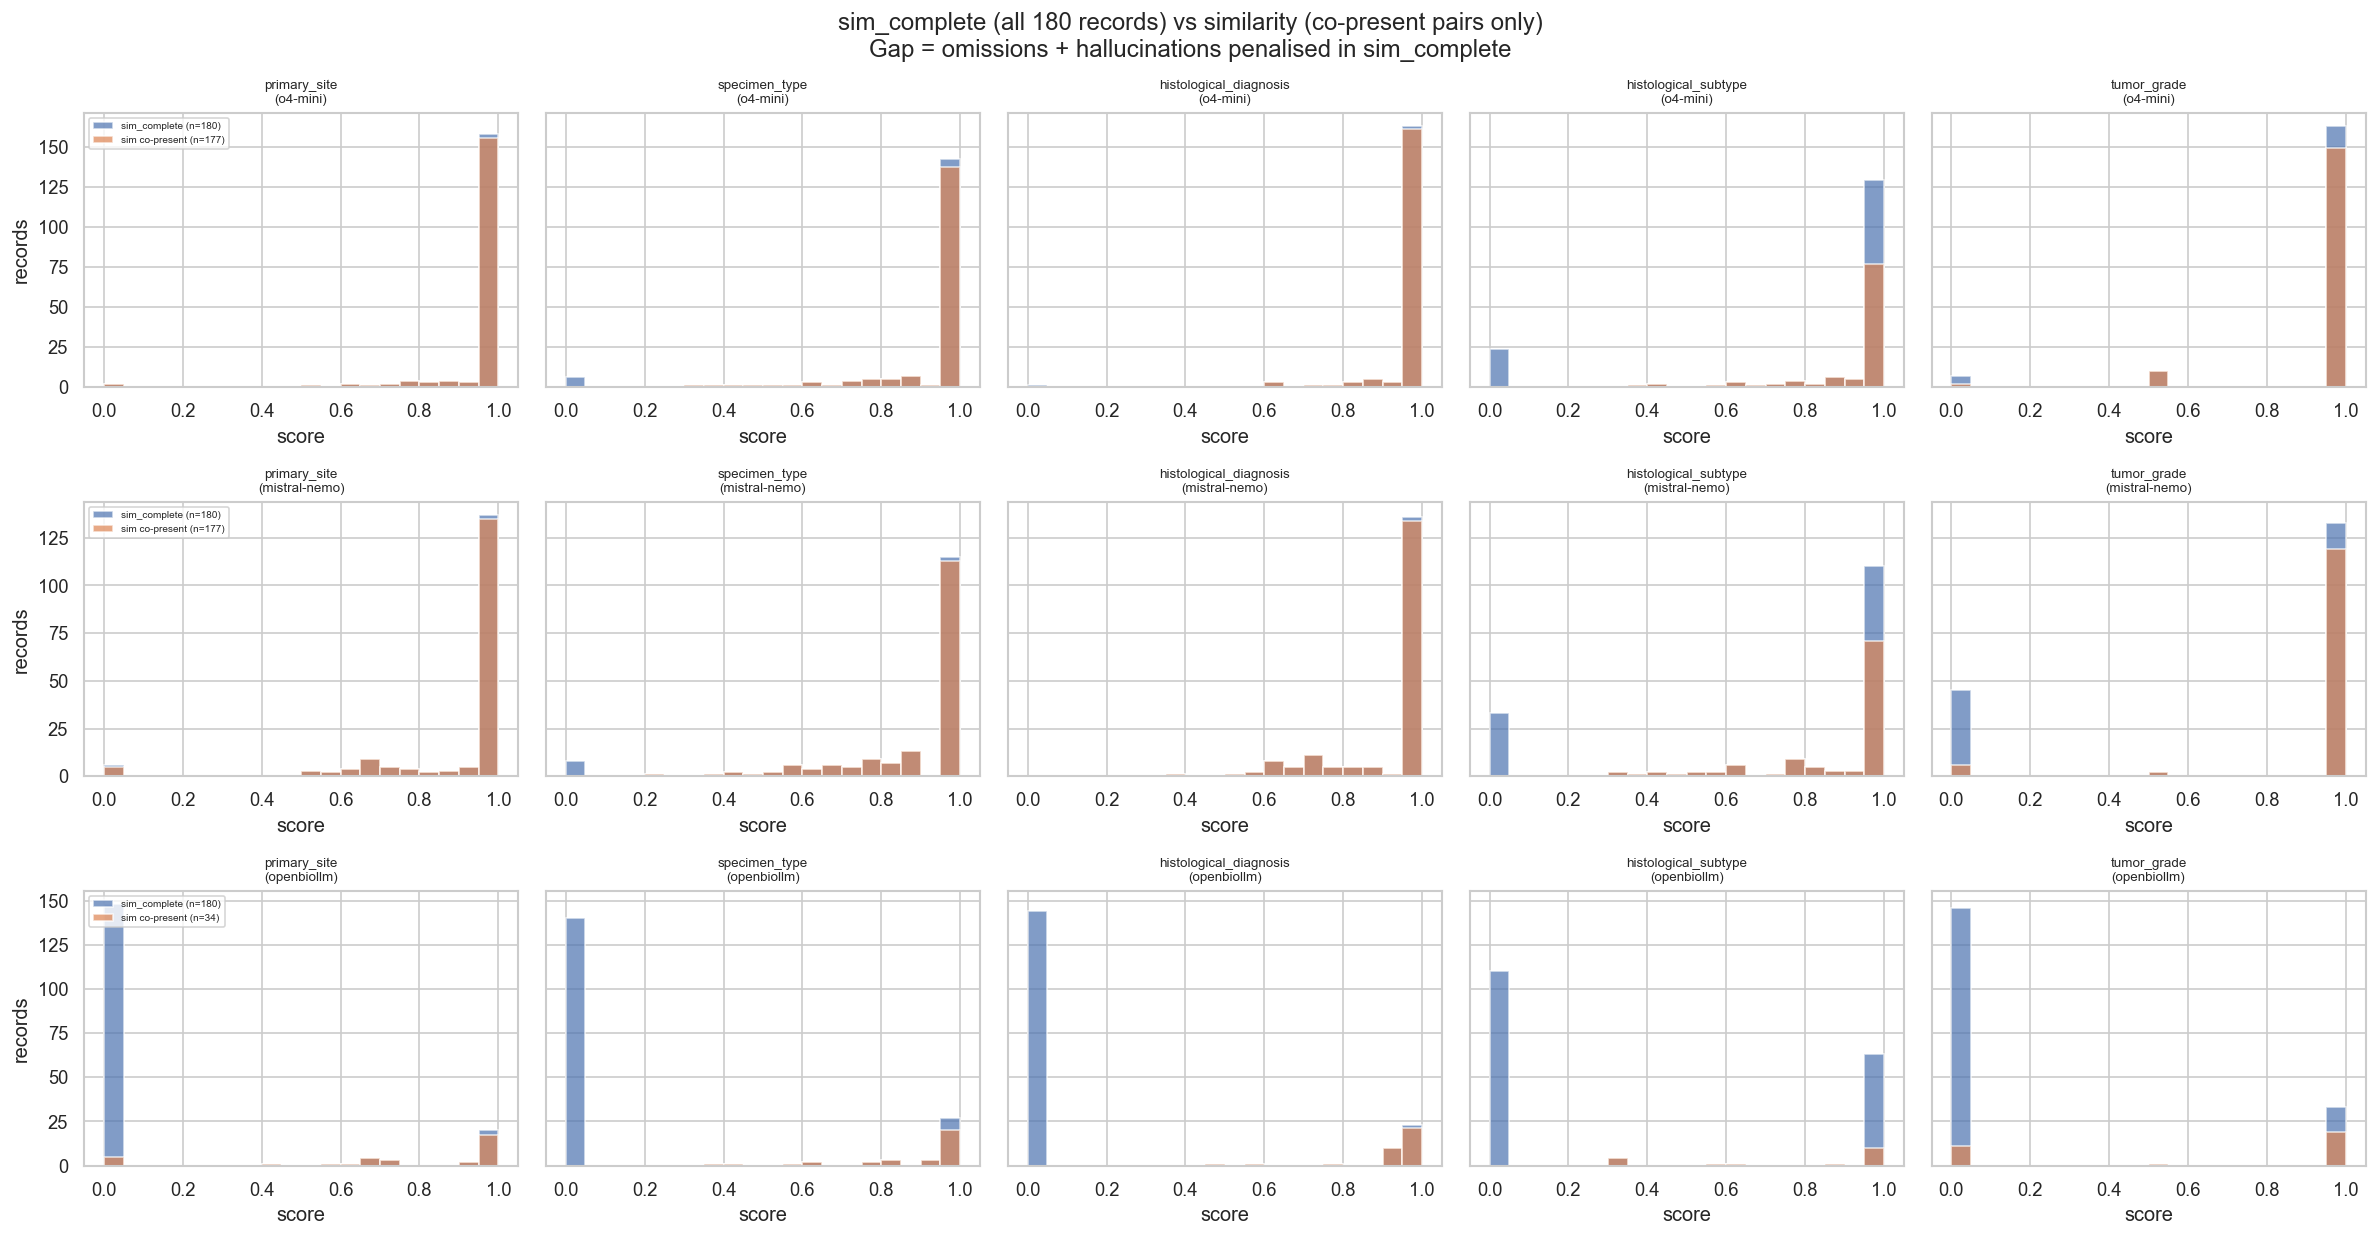

In [180]:
from src.evaluation.metrics import get_field_value
from src.evaluation.semantic import semantic_score


def collect_pairs(preds, golds):
    pred_map = {r["report_id"]: r for r in preds}
    pairs = {f: [] for f in SEMANTIC_FIELDS}
    for g in golds:
        p = pred_map.get(g["report_id"], {})
        for f in SEMANTIC_FIELDS:
            pv, gv = get_field_value(p, f), get_field_value(g, f)
            s = semantic_score(pv, gv, f)
            if s is not None:
                pairs[f].append((s, pv, gv))
    return pairs


def collect_complete_scores(preds, golds):
    pred_map = {r["report_id"]: r for r in preds}
    scores = {f: [] for f in SEMANTIC_FIELDS}
    for g in golds:
        p = pred_map.get(g["report_id"], {})
        for f in SEMANTIC_FIELDS:
            pv, gv = get_field_value(p, f), get_field_value(g, f)
            if pv is None and gv is None:
                s = 1.0
            elif gv is not None and pv is None:
                s = 0.0
            elif gv is None and pv is not None:
                s = 0.0
            else:
                computed = semantic_score(pv, gv, f)
                s = computed if computed is not None else 0.0
            scores[f].append(s)
    return scores


pairs_o4     = collect_pairs(preds_o4mini,     ground_truth)
pairs_llama3 = collect_pairs(preds_llama3,     ground_truth)
pairs_obio   = collect_pairs(preds_openbiollm, ground_truth)
complete_o4  = collect_complete_scores(preds_o4mini,     ground_truth)
complete_ll  = collect_complete_scores(preds_llama3,     ground_truth)
complete_ob  = collect_complete_scores(preds_openbiollm, ground_truth)

model_complete = [
    ("o4-mini",      pairs_o4,     complete_o4),
    ("mistral-nemo", pairs_llama3, complete_ll),
    ("openbiollm",   pairs_obio,   complete_ob),
]

fig, axes = plt.subplots(len(model_complete), len(SEMANTIC_FIELDS),
                          figsize=(20, 3.5 * len(model_complete)), sharey="row")

for row_i, (label, pairs, complete) in enumerate(model_complete):
    for ax, field in zip(axes[row_i], SEMANTIC_FIELDS):
        sc = complete[field]
        cp = [s for s, _, _ in pairs[field]]
        ax.hist(sc, bins=20, range=(0, 1), color="#4C72B0", edgecolor="white",
                alpha=0.7, label=f"sim_complete (n={len(sc)})")
        ax.hist(cp, bins=20, range=(0, 1), color="#DD8452", edgecolor="white",
                alpha=0.7, label=f"sim co-present (n={len(cp)})")
        ax.set_title(f"{field}\n({label})", fontsize=8)
        ax.set_xlabel("score")
    axes[row_i][0].set_ylabel("records")
    axes[row_i][0].legend(fontsize=6, loc="upper left")

plt.suptitle(
    "sim_complete (all 180 records) vs similarity (co-present pairs only)\n"
    "Gap = omissions + hallucinations penalised in sim_complete"
)
plt.tight_layout()
plt.show()


### 9.2 Audit Table

The metric's leniency must stay inspectable. Two views over all non-exact pairs:
- **Top of the table** (high similarity, exact-match rejected): these should be *same-concept wording differences*. If a wrong-concept pair appears here with a high score, the metric is too lenient for that field.
- **Bottom of the table** (lowest scores): these should be *genuine disagreements* — wrong concept, wrong laterality (forced to 0.0), or wrong grade.

These histograms and this table are also the designated input for a future binary-threshold decision (out of scope for Feature 8).

In [181]:
f1_o4 = fm_o4mini.set_index("field")["f1"].to_dict()

audit_rows = [
    {"field": f, "field_exact_f1": f1_o4.get(f), "score": round(s, 3), "pred": pv, "gold": gv}
    for f in SEMANTIC_FIELDS
    for s, pv, gv in pairs_o4[f]
    if s < 1.0
]
audit_df = pd.DataFrame(audit_rows).sort_values("score", ascending=False).reset_index(drop=True)

print(f"{len(audit_df)} non-exact pairs (o4-mini)")
print("\nHighest-similarity pairs rejected by exact match — should be same-concept wording differences:")
display(audit_df.head(15))
print("\nLowest-scoring pairs — should be genuine disagreements:")
display(audit_df.tail(15))

131 non-exact pairs (o4-mini)

Highest-similarity pairs rejected by exact match — should be same-concept wording differences:


,field,field_exact_f1,score,pred,gold
0,histol...,0.879,0.986,squamo...,squamo...
1,primar...,0.814,0.984,breast,breast...
2,histol...,0.638,0.984,lepidi...,lepidi...
3,specim...,0.773,0.984,mastec...,mastec...
4,specim...,0.773,0.980,wedge ...,wedge ...
5,primar...,0.814,0.979,left u...,left l...
6,primar...,0.814,0.979,left u...,left l...
7,primar...,0.814,0.978,right ...,right ...
8,primar...,0.814,0.978,right ...,right ...
9,primar...,0.814,0.978,right ...,right ...



Lowest-scoring pairs — should be genuine disagreements:


,field,field_exact_f1,score,pred,gold
116,tumor_...,0.520,0.500,poorly...,modera...
117,tumor_...,0.520,0.500,Grade 2,Grade ...
118,tumor_...,0.520,0.500,Grade 3,Grade ...
119,tumor_...,0.520,0.500,poorly...,Grade 3-4
120,specim...,0.773,0.453,multip...,mastec...
121,specim...,0.773,0.446,resection,mastec...
122,histol...,0.638,0.442,minor ...,lobular
123,histol...,0.638,0.412,cribri...,adenoi...
124,histol...,0.638,0.377,spindl...,NST
125,specim...,0.773,0.350,excisi...,partia...


In [182]:
for model_label, fm_df, pairs in [
    ("o4-mini",      fm_o4mini,     pairs_o4),
    ("mistral-nemo", fm_llama3,     pairs_llama3),
    ("openbiollm",   fm_openbiollm, pairs_obio),
]:
    if fm_df.empty or not any(pairs.values()):
        continue
    f1_map = fm_df.set_index("field")["f1"].to_dict()
    audit_rows = [
        {"field": f, "field_exact_f1": f1_map.get(f), "score": round(s, 3), "pred": pv, "gold": gv}
        for f in SEMANTIC_FIELDS
        for s, pv, gv in pairs[f]
        if s < 1.0
    ]
    audit_df = pd.DataFrame(audit_rows).sort_values("score", ascending=False).reset_index(drop=True)
    print(f"\n{len(audit_df)} non-exact pairs ({model_label})")
    print("Highest-similarity pairs (same-concept wording differences):")
    display(audit_df.head(10))
    print("Lowest-scoring pairs (genuine disagreements):")
    display(audit_df.tail(10))



131 non-exact pairs (o4-mini)
Highest-similarity pairs (same-concept wording differences):


,field,field_exact_f1,score,pred,gold
0,histol...,0.879,0.986,squamo...,squamo...
1,primar...,0.814,0.984,breast,breast...
2,histol...,0.638,0.984,lepidi...,lepidi...
3,specim...,0.773,0.984,mastec...,mastec...
4,specim...,0.773,0.980,wedge ...,wedge ...
5,primar...,0.814,0.979,left u...,left l...
6,primar...,0.814,0.979,left u...,left l...
7,primar...,0.814,0.978,right ...,right ...
8,primar...,0.814,0.978,right ...,right ...
9,primar...,0.814,0.978,right ...,right ...


Lowest-scoring pairs (genuine disagreements):


,field,field_exact_f1,score,pred,gold
121,specim...,0.773,0.446,resection,mastec...
122,histol...,0.638,0.442,minor ...,lobular
123,histol...,0.638,0.412,cribri...,adenoi...
124,histol...,0.638,0.377,spindl...,NST
125,specim...,0.773,0.350,excisi...,partia...
126,specim...,0.773,0.310,excision,breast...
127,primar...,0.814,0.000,left b...,right ...
128,tumor_...,0.520,0.000,Grade 3,Grade 2
129,primar...,0.814,0.000,right ...,bilate...
130,tumor_...,0.520,0.000,poorly...,Grade ...



234 non-exact pairs (mistral-nemo)
Highest-similarity pairs (same-concept wording differences):


...

,field,field_exact_f1,score,pred,gold
224,primar...,0.597,0.000,right ...,left b...
225,tumor_...,0.526,0.000,well-d...,Grade ...
226,tumor_...,0.526,0.000,Grade 2,Grade 3
227,tumor_...,0.526,0.000,Grade 3,Grade 2
228,primar...,0.597,0.000,left b...,right ...
229,tumor_...,0.526,0.000,Grade 2,Grade 3
230,tumor_...,0.526,0.000,Grade 3,Grade ...
231,primar...,0.597,0.000,right ...,bilate...
232,primar...,0.597,0.000,left b...,left b...
233,primar...,0.597,0.000,left b...,left b...



64 non-exact pairs (openbiollm)
Highest-similarity pairs (same-concept wording differences):


,field,field_exact_f1,score,pred,gold
0,histol...,0.189,0.964,infilt...,invasi...
1,histol...,0.111,0.961,"mixed,...","mixed,..."
2,primar...,0.161,0.939,right ...,right ...
3,histol...,0.189,0.936,infilt...,invasi...
4,histol...,0.189,0.936,infilt...,invasi...
5,histol...,0.189,0.936,infilt...,invasi...
6,histol...,0.189,0.936,infilt...,invasi...
7,histol...,0.189,0.936,infilt...,invasi...
8,specim...,0.194,0.934,radica...,modifi...
9,primar...,0.161,0.928,left b...,left b...


Lowest-scoring pairs (genuine disagreements):


,field,field_exact_f1,score,pred,gold
54,tumor_...,0.142,0.000,Grade 3,Grade 2
55,tumor_...,0.142,0.000,Grade 3,Grade 2
56,tumor_...,0.142,0.000,Grade 3,Grade ...
57,tumor_...,0.142,0.000,Grade 3,Grade 2
58,primar...,0.161,0.000,left b...,right ...
59,tumor_...,0.142,0.000,Grade 3,Grade ...
60,primar...,0.161,0.000,left b...,right ...
61,primar...,0.161,0.000,right ...,left l...
62,primar...,0.161,0.000,right ...,bilate...
63,primar...,0.161,0.000,left b...,right ...


### 9.3 Zero-Shot Sanity Check

The 12 few-shot examples are the only annotated data outside the frozen eval set. They cannot be scored through the normal pipeline (the model would see its own answers in the prompt), so they are run **zero-shot** — same prompt template, no `--few-shot` flag. The resulting pred/gold pairs, sorted ascending by score, are the held-out sanity check: same-concept pairs should score visibly higher than different-concept pairs.

**Known limitation to remember when reading:** acronym pairs (e.g. `NST` vs `NOS (no special type)`) can score low even when clinically equivalent — SapBERT works on surface forms, and short acronyms carry little signal.

In [183]:
zs_path = ROOT / "data/processed/zero_shot_sanity_v1.jsonl"
fs_path = ROOT / "data/annotations/few_shot_examples_v1.4.jsonl"

if zs_path.exists():
    zs_preds = load_jsonl(zs_path)
    zs_golds = [{**r["ground_truth"], "report_id": r["report_id"]} for r in load_jsonl(fs_path)]
    zs_pairs = collect_pairs(zs_preds, zs_golds)
    zs_df = pd.DataFrame([
        {"field": f, "score": round(s, 3), "pred": pv, "gold": gv}
        for f in SEMANTIC_FIELDS for s, pv, gv in zs_pairs[f] if s < 1.0
    ]).sort_values("score").reset_index(drop=True)
    print(f"{len(zs_preds)} zero-shot predictions; {len(zs_df)} non-exact pairs (sorted ascending):")
    display(zs_df)
else:
    print("Zero-shot results not found — generate with:")
    print("  uv run python -m src.pipeline.run_pipeline \\")
    print("    --input data/annotations/few_shot_examples_v1.4.jsonl \\")
    print("    --output data/processed/zero_shot_sanity_v1.jsonl --model openai:o4-mini")

12 zero-shot predictions; 17 non-exact pairs (sorted ascending):


,field,score,pred,gold
0,histol...,0.513,giant-...,large-...
1,histol...,0.563,mixed,"mixed,..."
2,histol...,0.699,papill...,"mixed,..."
3,histol...,0.717,invasi...,squamo...
4,primar...,0.733,right ...,right ...
5,histol...,0.756,mixed ...,adenoc...
6,histol...,0.834,pleomo...,lobula...
7,primar...,0.899,left lung,left l...
8,histol...,0.910,lobula...,invasi...
9,histol...,0.936,invasi...,infilt...


### 9.4 Prediction vs Ground Truth — o4-mini Side-by-Side

One row per record. For each field: `pred` column shows what o4-mini extracted, `gt` column shows the annotated ground truth.

> See §14 for the full 3-model inspector with hallucination flags and extraction notes.


In [184]:
from src.evaluation.metrics import get_field_value, ALL_FIELDS

# Build GT lookup keyed by report_id
gt_lookup = {r["report_id"]: r for r in ground_truth}

rows = []
for pred in preds_o4mini:
    rid = pred["report_id"]
    gt = gt_lookup.get(rid)
    if gt is None:
        continue
    row = {"report_id": rid}
    for field in ALL_FIELDS:
        row[f"{field}_pred"] = get_field_value(pred, field)
        row[f"{field}_gt"] = get_field_value(gt, field)
    rows.append(row)

df_comparison = pd.DataFrame(rows)

# Reorder columns: report_id, then per-field pairs
ordered_cols = ["report_id"]
for field in ALL_FIELDS:
    ordered_cols += [f"{field}_pred", f"{field}_gt"]
df_comparison = df_comparison[ordered_cols]

print(f"{len(df_comparison)} records | {len(ALL_FIELDS)} fields")
df_comparison

180 records | 8 fields


,report_id,primary_site_pred,primary_site_gt,specimen_type_pred,specimen_type_gt,histological_diagnosis_pred,histological_diagnosis_gt,histological_subtype_pred,histological_subtype_gt,tumor_grade_pred,tumor_grade_gt,tnm_stage.T_pred,tnm_stage.T_gt,tnm_stage.N_pred,tnm_stage.N_gt,tnm_stage.M_pred,tnm_stage.M_gt
0,TCGA-A...,left b...,left b...,mastec...,mastec...,invasi...,infilt...,minor ...,lobular,Grade 2,Grade ...,pT3,pT3,pN1a,pN1a,pMX,pMX
1,TCGA-A...,right ...,right ...,total ...,total ...,invasi...,invasi...,None,lobular,Grade 2,Grade 2,pT3,pT3,pN2,pN2,None,None
2,TCGA-B...,right ...,right ...,needle...,segmen...,invasi...,invasi...,NST,NST,Grade 1,Grade 1,pT1c,pT1c,pN1,pN1,pMX,pMX
3,TCGA-A...,right ...,right ...,simple...,simple...,invasi...,invasi...,None,lobular,Grade 2,Grade 2,pT3,pT3,pN0,pN0(sn),pMX,pMX
4,TCGA-E...,right ...,right ...,mastec...,mastec...,invasi...,invasi...,pleomo...,lobula...,None,None,pT3,pT3,pN3,pN3,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,TCGA-3...,lung,lung (...,OCT block,None,squamo...,squamo...,None,None,Grade 2,Grade 2,T2,T2,N0,N0,M1,M1
176,TCGA-1...,left l...,left l...,lobectomy,lobect...,squamo...,squamo...,None,None,poorly...,Grade ...,pT2,pT2,pN1,pN1,pMX,pMX
177,TCGA-2...,left l...,left l...,left p...,pneumo...,squamo...,squamo...,None,None,Grade 3,Grade ...,pT2,pT2b,pN0,pN0,None,None
178,TCGA-6...,left l...,left l...,lobectomy,lobect...,squamo...,squamo...,nonker...,large-...,poorly...,Grade ...,pT2,pT2,pN1,pN0,None,None


## 10. Hallucination Flag Analysis

Where do models produce values the validator rejects? Flag rate, flag taxonomy, and specific unrecognised grade values per model.


,total_valid,n_flagged,hallucination_rate
model,,,
o4-mini,180,1,0.6%
mistral-nemo,180,28,15.6%
openbiollm,180,7,3.9%


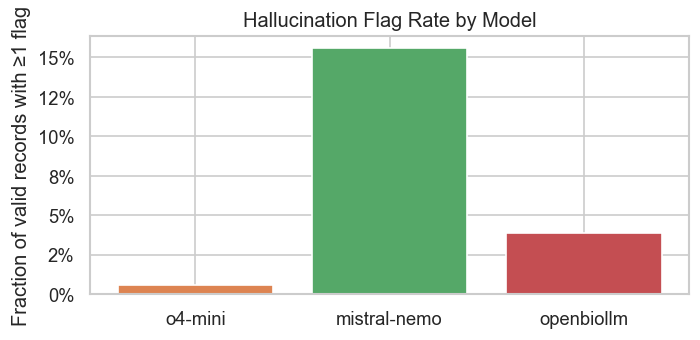

In [185]:
from collections import Counter

# 10.1 Flag rate by model
hallu_data = []
for model_label, preds in [
    ("o4-mini",      preds_o4mini),
    ("mistral-nemo", preds_llama3),
    ("openbiollm",   preds_openbiollm),
]:
    if not preds:
        continue
    valid   = [r for r in preds if r.get("validation_status") in ("valid", "vocab_flagged")]
    flagged = [r for r in valid if r.get("hallucination_flags")]
    hallu_data.append({
        "model":              model_label,
        "total_valid":        len(valid),
        "n_flagged":          len(flagged),
        "hallucination_rate": len(flagged) / len(valid) if valid else 0.0,
    })

hallu_df = pd.DataFrame(hallu_data).set_index("model")
display(hallu_df.style
    .format({"hallucination_rate": "{:.1%}"})
    .set_caption("Hallucination flag rate per model (fraction of valid records with ≥1 flag)"))

fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(hallu_df.index, hallu_df["hallucination_rate"],
       color=["#DD8452", "#55A868", "#C44E52"])
ax.set_ylabel("Fraction of valid records with ≥1 flag")
ax.set_title("Hallucination Flag Rate by Model")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
plt.tight_layout()
plt.show()


model,mistral-nemo,o4-mini,openbiollm
flag_type,,,
invalid_tnm_M,2,0,1
invalid_tnm_N,10,0,1
invalid_tnm_T,1,1,1
no_pathology_report,2,0,0
unrecognised_grade,15,0,4


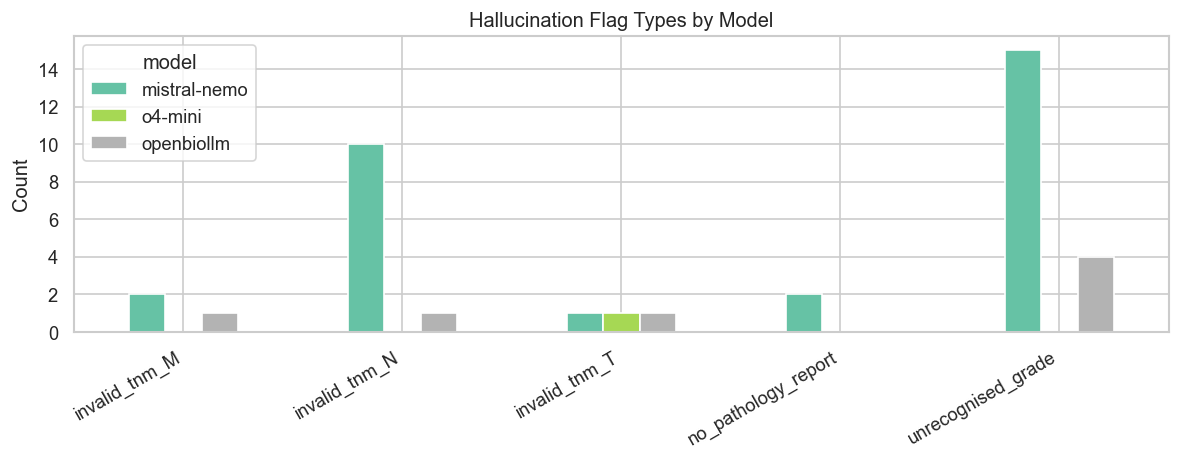

In [186]:
# 10.2 Flag taxonomy
flag_rows = []
for model_label, preds in [
    ("o4-mini",      preds_o4mini),
    ("mistral-nemo", preds_llama3),
    ("openbiollm",   preds_openbiollm),
]:
    if not preds:
        continue
    all_flags = [flag for r in preds for flag in (r.get("hallucination_flags") or [])]
    for flag in all_flags:
        prefix = flag.split(":")[0].strip()
        flag_rows.append({"model": model_label, "flag_type": prefix})

flag_df = pd.DataFrame(flag_rows)
if not flag_df.empty:
    pivot = flag_df.groupby(["model", "flag_type"]).size().reset_index(name="count")
    pivot_wide = pivot.pivot(index="flag_type", columns="model", values="count").fillna(0).astype(int)
    display(pivot_wide.style
        .background_gradient(cmap="Oranges")
        .set_caption("Flag type × model — count across all 180 records"))

    pivot_wide.plot(kind="bar", figsize=(10, 4), colormap="Set2")
    plt.title("Hallucination Flag Types by Model")
    plt.xlabel("")
    plt.ylabel("Count")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No hallucination flags across any model.")


In [187]:
# 10.3 Unrecognised grade values per model
for model_label, preds in [
    ("o4-mini",      preds_o4mini),
    ("mistral-nemo", preds_llama3),
    ("openbiollm",   preds_openbiollm),
]:
    if not preds:
        continue
    grade_flags = [
        flag for r in preds
        for flag in (r.get("hallucination_flags") or [])
        if flag.startswith("unrecognised_grade")
    ]
    if not grade_flags:
        print(f"{model_label}: no unrecognised_grade flags")
        continue
    oov_terms = [f.split(": ", 1)[1].strip("'\"") for f in grade_flags]
    oov_df = pd.DataFrame(Counter(oov_terms).most_common(), columns=["predicted_grade", "count"])
    display(oov_df.style.set_caption(f"Unrecognised grade values — {model_label}"))


o4-mini: no unrecognised_grade flags


,predicted_grade,count
0,Grade II,2
1,Grade 2 (moderately differentiated),2
2,Grade II of III,1
3,Grade 2/4,1
4,well-differentiated,1
5,Grade 3 (poorly differentiated),1
6,Grade 2/3 (moderately differentiated),1
7,Grade II-III/III,1
8,Grade 1 (good nuclear grade),1
9,Grade 2/3,1


,predicted_grade,count
0,Grade 2 (of III),1
1,Grade II (of III),1
2,Grade 2 (of 3) - Nottingham grade II,1
3,Grade 3 (intermediate nuclear grade),1


## 11. Field-Level Failure Heatmap

Rows = 8 fields, columns = 3 models. Shows which field × model combinations are weakest and how errors are distributed.


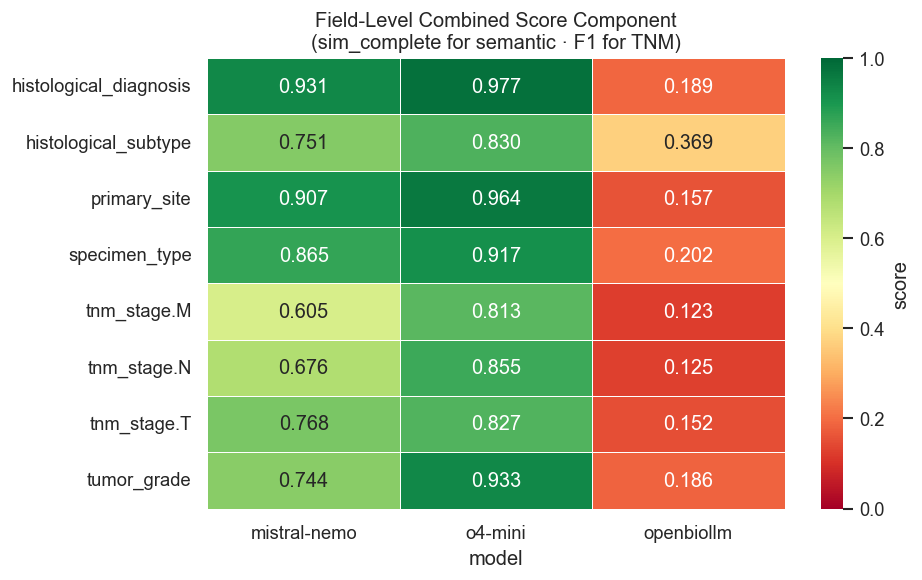

In [188]:
# 11.1 Combined-score component heatmap (sim_complete for semantic, F1 for TNM)
hm_rows = []
for model_label, preds in [
    ("o4-mini",      preds_o4mini),
    ("mistral-nemo", preds_llama3),
    ("openbiollm",   preds_openbiollm),
]:
    if not preds:
        continue
    fm_list  = compute_all_field_metrics(preds, ground_truth)
    sem_list = compute_semantic_metrics(preds, ground_truth)
    f1_map   = {fm.field: fm.f1 for fm in fm_list}
    sc_map   = {sm.field: sm.mean_similarity_complete for sm in sem_list}
    for field in ALL_FIELDS:
        val = sc_map.get(field, f1_map.get(field, 0.0))
        hm_rows.append({"field": field, "model": model_label, "score": round(val, 3)})

hm_df = pd.DataFrame(hm_rows).pivot(index="field", columns="model", values="score")

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(hm_df, annot=True, fmt=".3f", cmap="RdYlGn", vmin=0, vmax=1,
            linewidths=0.5, ax=ax, cbar_kws={"label": "score"})
ax.set_title("Field-Level Combined Score Component\n(sim_complete for semantic · F1 for TNM)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


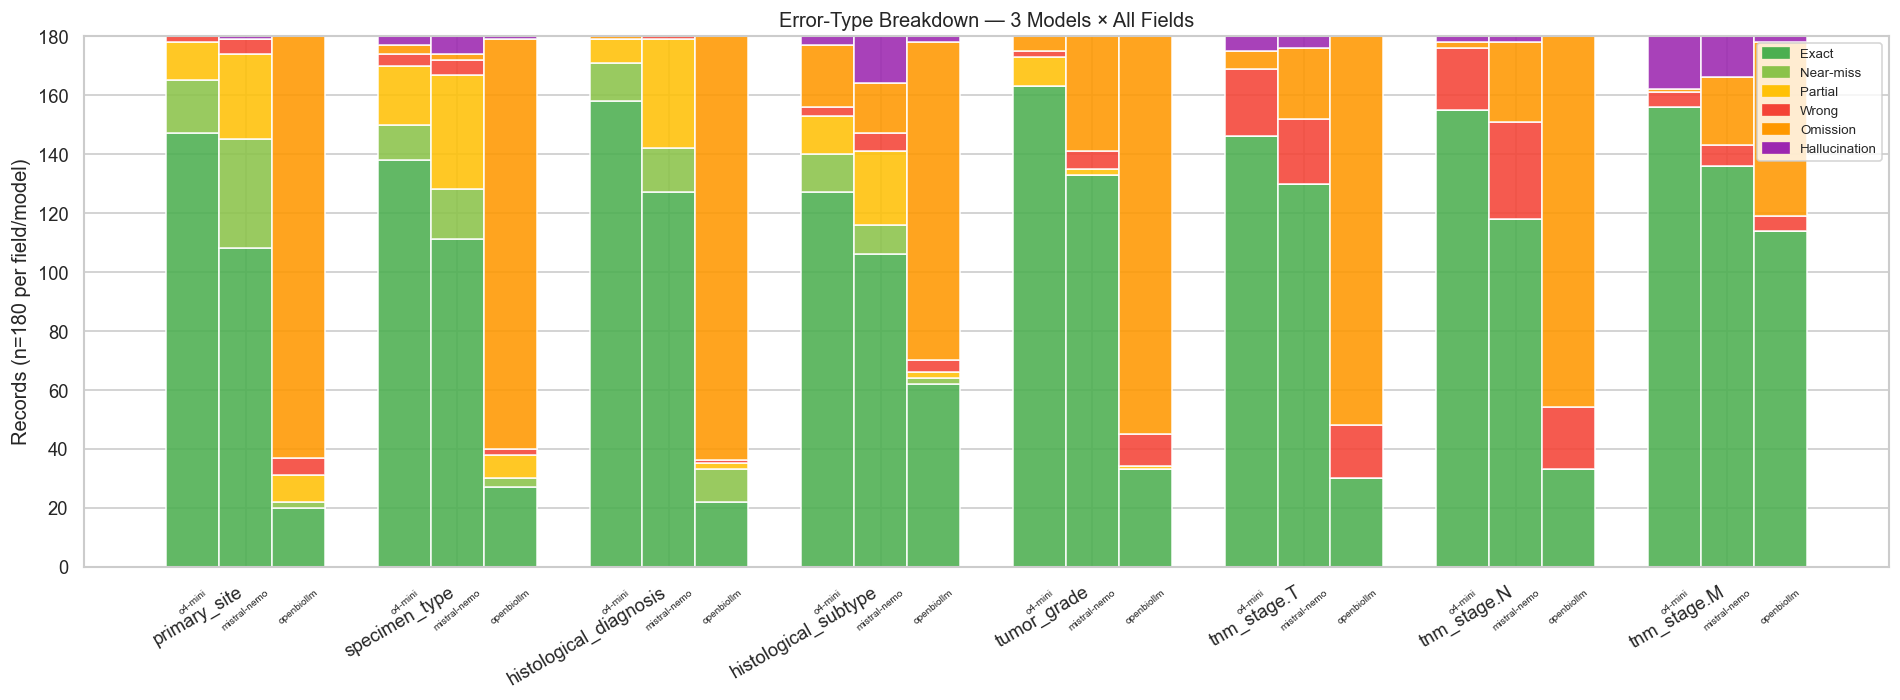

In [189]:
# 11.2 Error-type stacked bars — 3 models × all fields
ERROR_TYPES  = ["Exact", "Near-miss", "Partial", "Wrong", "Omission", "Hallucination"]
ERROR_COLORS = {
    "Exact": "#4CAF50", "Near-miss": "#8BC34A", "Partial": "#FFC107",
    "Wrong": "#F44336", "Omission": "#FF9800", "Hallucination": "#9C27B0",
}
MODELS_ORDER = ["o4-mini", "mistral-nemo", "openbiollm"]
eb_three = pd.concat([eb_o4, eb_ll, eb_ob], ignore_index=True)

n_fields = len(ALL_FIELDS)
width    = 0.25
x        = range(n_fields)

fig, ax = plt.subplots(figsize=(16, 6))
for mi, model in enumerate(MODELS_ORDER):
    sub = eb_three[eb_three["model"] == model]
    if sub.empty:
        continue
    sub    = sub.set_index("field")
    bottom = [0] * n_fields
    offsets = [xi + (mi - 1) * width for xi in x]
    for etype in ERROR_TYPES:
        vals = [sub.loc[f, etype] if f in sub.index else 0 for f in ALL_FIELDS]
        ax.bar(offsets, vals, width, bottom=bottom,
               color=ERROR_COLORS[etype],
               label=etype if mi == 0 else "_nolegend_", alpha=0.88)
        bottom = [b + v for b, v in zip(bottom, vals)]
    for xi, offset in zip(x, offsets):
        ax.text(offset, -7, model, ha="center", va="top", fontsize=6, rotation=40)

ax.set_xticks(list(x))
ax.set_xticklabels(ALL_FIELDS, rotation=30, ha="right")
ax.set_ylabel("Records (n=180 per field/model)")
ax.set_title("Error-Type Breakdown — 3 Models × All Fields")
handles = [plt.Rectangle((0, 0), 1, 1, color=ERROR_COLORS[e]) for e in ERROR_TYPES]
ax.legend(handles, ERROR_TYPES, loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()


## 12. Cross-Model Agreement

For each record × field: all 3 models correct → **All-correct**; all fail → **All-fail** (hard case or ambiguous GT); only some fail → **Mixed** (model-specific weakness). Counts must sum to 180 per field.


Row sums (must equal 180 per field):
field
histological_diagnosis    180
histological_subtype      180
primary_site              180
specimen_type             180
tnm_stage.M               180
tnm_stage.N               180
tnm_stage.T               180
tumor_grade               180



category,All-correct,Mixed,All-fail
field,,,
histological_diagnosis,29,147,4
histological_subtype,47,100,33
primary_site,19,149,12
specimen_type,15,151,14
tnm_stage.M,86,88,6
tnm_stage.N,27,133,20
tnm_stage.T,24,133,23
tumor_grade,32,141,7


/var/folders/8r/mwfqwtnd0xd7wgh0rvjzfkv00000gn/T/ipykernel_30339/3770984266.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(agree_pivot.index, rotation=30, ha="right")


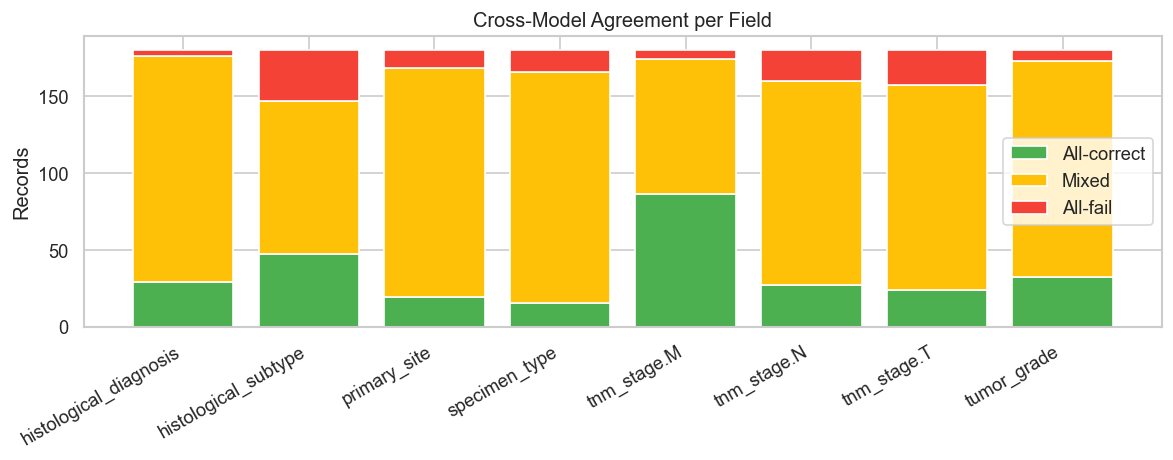

In [190]:
NEAR_MISS_THR = 0.85

def _is_correct(pred, gold, field):
    pv = get_field_value(pred, field)
    gv = get_field_value(gold, field)
    if pv is None and gv is None:
        return True
    if pv is None or gv is None:
        return False
    if field in SEMANTIC_FIELDS:
        s = _sem_score(pv, gv, field)
        return s is not None and s >= NEAR_MISS_THR
    return pv.strip().lower() == gv.strip().lower()


pred_maps_3 = {
    "o4-mini":      {r["report_id"]: r for r in preds_o4mini},
    "mistral-nemo": {r["report_id"]: r for r in preds_llama3},
    "openbiollm":   {r["report_id"]: r for r in preds_openbiollm},
}

agreement_rows = []
for g in ground_truth:
    rid = g["report_id"]
    for field in ALL_FIELDS:
        correct = {m: _is_correct(pred_maps_3[m].get(rid, {}), g, field) for m in pred_maps_3}
        n_ok    = sum(correct.values())
        cat     = "All-correct" if n_ok == 3 else ("All-fail" if n_ok == 0 else "Mixed")
        agreement_rows.append({"field": field, "report_id": rid, "category": cat})

agree_df = pd.DataFrame(agreement_rows)

agree_summary = agree_df.groupby(["field", "category"]).size().reset_index(name="count")
agree_pivot   = agree_summary.pivot(index="field", columns="category", values="count").fillna(0).astype(int)
for col in ["All-correct", "Mixed", "All-fail"]:
    if col not in agree_pivot.columns:
        agree_pivot[col] = 0
agree_pivot = agree_pivot[["All-correct", "Mixed", "All-fail"]]

print("Row sums (must equal 180 per field):")
print(agree_pivot.sum(axis=1).to_string())
print()
display(agree_pivot.style
    .background_gradient(subset=["All-correct"], cmap="Greens", vmin=0, vmax=180)
    .background_gradient(subset=["All-fail"],    cmap="Reds",   vmin=0, vmax=60)
    .set_caption(
        "Cross-model agreement per field (n=180 records).  "
        "All-fail = hard case or ambiguous GT.  Mixed = model-specific weakness."
    ))

AGREE_COLORS = {"All-correct": "#4CAF50", "Mixed": "#FFC107", "All-fail": "#F44336"}
fig, ax = plt.subplots(figsize=(10, 4))
bottom = [0] * len(agree_pivot)
for cat in ["All-correct", "Mixed", "All-fail"]:
    ax.bar(agree_pivot.index, agree_pivot[cat], bottom=bottom,
           label=cat, color=AGREE_COLORS[cat])
    bottom = [b + v for b, v in zip(bottom, agree_pivot[cat])]
ax.set_xticklabels(agree_pivot.index, rotation=30, ha="right")
ax.set_ylabel("Records")
ax.set_title("Cross-Model Agreement per Field")
ax.legend()
plt.tight_layout()
plt.show()


In [191]:
agree_df[agree_df["category"] == 'All-fail']

,field,report_id,category
5,tnm_st...,TCGA-A...,All-fail
8,primar...,TCGA-A...,All-fail
11,histol...,TCGA-A...,All-fail
19,histol...,TCGA-A...,All-fail
35,histol...,TCGA-A...,All-fail
...,...,...,...
1406,tnm_st...,TCGA-6...,All-fail
1420,tumor_...,TCGA-2...,All-fail
1421,tnm_st...,TCGA-2...,All-fail
1422,tnm_st...,TCGA-2...,All-fail


In [192]:
### 12.1  All-fail record inspector
# For each field, show up to 5 records where every model was wrong.
# field_score = score for the inspected field only (0.0 = hallucination or omission).
# Sorted by mean field_score across models (lowest first).

N_SHOW = 5
gt_map = {r['report_id']: r for r in ground_truth}

all_fail_df = agree_df[agree_df['category'] == 'All-fail'].copy()

def _field_score(pred, gold, field):
    pv, gv = get_field_value(pred, field), get_field_value(gold, field)
    if pv is None and gv is None:
        return 1.0
    if pv is None or gv is None:
        return 0.0
    if field in SEMANTIC_FIELDS:
        s = _sem_score(pv, gv, field)
        return round(s, 3) if s is not None else 0.0
    return 1.0 if pv.strip().lower() == gv.strip().lower() else 0.0

for field in ALL_FIELDS:
    rids = all_fail_df[all_fail_df['field'] == field]['report_id'].tolist()
    if not rids:
        print(f'\n{field}: no All-fail records')
        continue
    print(f'\n── {field}  ({len(rids)} All-fail records, showing up to {N_SHOW}) ──')
    rows = []
    for rid in rids:
        g   = gt_map.get(rid, {})
        row = {
            'report_id':   rid,
            'cancer_type': g.get('cancer_type', ''),
            'GT':          get_field_value(g, field),
        }
        mean_scores = []
        for model_label in ['o4-mini', 'mistral-nemo', 'openbiollm']:
            p = pred_maps_3[model_label].get(rid, {})
            fs = _field_score(p, g, field)
            row[f'{model_label} pred']        = get_field_value(p, field)
            row[f'{model_label} field_score'] = fs
            mean_scores.append(fs)
        row['mean_field_score'] = round(sum(mean_scores) / len(mean_scores), 3)
        rows.append(row)
    df = (
        pd.DataFrame(rows)
        .sort_values('mean_field_score')
        .head(N_SHOW)
        .drop(columns='mean_field_score')
        .set_index('report_id')
    )
    display(df)



── primary_site  (12 All-fail records, showing up to 5) ──


,cancer_type,GT,o4-mini pred,o4-mini field_score,mistral-nemo pred,mistral-nemo field_score,openbiollm pred,openbiollm field_score
report_id,,,,,,,,
TCGA-AR-A2LQ.C3537961-4636-4BD1-BC89-892580B36E43,BRCA,right ...,left b...,0.000,left b...,0.000,None,0.000
TCGA-AR-A2LN.128D4F7D-017D-459F-9664-AF509AE4555E,BRCA,bilate...,right ...,0.000,right ...,0.000,right ...,0.000
TCGA-55-7816.ca0d6f7a-fee3-49c5-8239-8a2583cecdd1,LUAD,right ...,right ...,0.637,right ...,0.516,None,0.000
TCGA-50-5933.68d471f3-43c0-44cf-97ce-003ff111c35c,LUAD,left l...,left l...,0.638,left l...,0.638,right ...,0.000
TCGA-AO-A0JF.D58E5D64-B5B9-4487-8E46-225AE3617C14,BRCA,left b...,left b...,0.661,left b...,0.661,None,0.000



── specimen_type  (14 All-fail records, showing up to 5) ──


,cancer_type,GT,o4-mini pred,o4-mini field_score,mistral-nemo pred,mistral-nemo field_score,openbiollm pred,openbiollm field_score
report_id,,,,,,,,
TCGA-AN-A0FF.9B4BA15D-A071-4213-AD2C-075A04ED48CD,BRCA,None,surgic...,0.000,tumor ...,0.000,surger...,0.000
TCGA-EW-A3U0.8652E026-9C4D-4AB6-AADE-29DA3345892E,BRCA,partia...,excisi...,0.350,lumpec...,0.590,None,0.000
TCGA-A2-A1FX.EAFC71A1-D6FC-46EA-BC47-D054C497D705,BRCA,breast...,excision,0.310,breast...,0.699,None,0.000
TCGA-A8-A079.81ADDBAB-C02F-4DA8-9429-76293FB42E42,BRCA,mastec...,ablate...,0.529,ablate...,0.529,None,0.000
TCGA-44-8119.c40ea4c8-8cbe-4a44-96d4-ae524a916449,LUAD,en blo...,en blo...,0.714,en blo...,0.745,None,0.000



── histological_diagnosis  (4 All-fail records, showing up to 5) ──


...

,cancer_type,GT,o4-mini pred,o4-mini field_score,mistral-nemo pred,mistral-nemo field_score,openbiollm pred,openbiollm field_score
report_id,,,,,,,,
TCGA-AO-A12C.7E9202F6-F2DB-4CC0-A10F-3D9A82E84242,BRCA,pT2(m),pT2,0.000,pT2,0.000,None,0.000
TCGA-39-5016.7b50ffbc-010e-415b-8d85-b5639801e287,LUSC,pT3,pT2,0.000,pT2,0.000,None,0.000
TCGA-21-1079.ddcba444-a2bd-48cc-a035-553126bca0c6,LUSC,pT2b,pT2,0.000,None,0.000,None,0.000
TCGA-39-5036.b5f0955a-6175-4c71-ab34-639f8ac6d69a,LUSC,pT2a,pT2,0.000,pT2,0.000,None,0.000
TCGA-63-6202.b8730165-2c60-469b-ae9a-f630fd97016a,LUSC,T2,pT2,0.000,pT2,0.000,None,0.000



── tnm_stage.N  (20 All-fail records, showing up to 5) ──


,cancer_type,GT,o4-mini pred,o4-mini field_score,mistral-nemo pred,mistral-nemo field_score,openbiollm pred,openbiollm field_score
report_id,,,,,,,,
TCGA-AC-A4ZE.6931CAAE-6DFE-4A61-84D5-4EC804C2F2C6,BRCA,pN0(sn),pN0,0.000,pN0,0.000,None,0.000
TCGA-77-8133.6ddd0cb2-fea0-4b27-9468-ca4f085192d6,LUSC,N1,pN1,0.000,pN1,0.000,None,0.000
TCGA-55-6978.3e3c1e82-ee09-4eeb-873a-9b6580274f97,LUAD,pN0,None,0.000,None,0.000,None,0.000
TCGA-D8-A1JJ.3F1DA529-4967-462D-8966-E634D66EB3E1,BRCA,pN0(sn),pN0,0.000,None,0.000,pN0,0.000
TCGA-AR-A1AY.01D97550-C616-4001-85A5-5502D35FA38E,BRCA,pN0(i+...,pN0(i+),0.000,pNO(i+),0.000,None,0.000



── tnm_stage.M  (6 All-fail records, showing up to 5) ──


,cancer_type,GT,o4-mini pred,o4-mini field_score,mistral-nemo pred,mistral-nemo field_score,openbiollm pred,openbiollm field_score
report_id,,,,,,,,
TCGA-AN-A0XU.8216B837-DCF3-4E7F-A72A-212655F394F0,BRCA,M0,pM0,0.000,None,0.000,None,0.000
TCGA-AN-A0FF.9B4BA15D-A071-4213-AD2C-075A04ED48CD,BRCA,M0,pM0,0.000,None,0.000,pM0,0.000
TCGA-AN-A04D.A3CB59DE-5893-4FA2-B4D5-EDA612480E76,BRCA,M0,pM0,0.000,None,0.000,pM0,0.000
TCGA-AO-A0J5.5EFC16F4-7FC7-479E-93F7-AEDC2D350A22,BRCA,M1,None,0.000,None,0.000,None,0.000
TCGA-77-8133.6ddd0cb2-fea0-4b27-9468-ca4f085192d6,LUSC,MX,pMX,0.000,pMX,0.000,None,0.000


## 13. Failure Patterns by Covariate

Combined score and null rates broken down by cancer type, report style, and field, to find whether failures cluster on specific report characteristics.


model,mistral-nemo,o4-mini,openbiollm
stratum,,,
BRCA,0.776,0.870,0.158
LUAD,0.769,0.907,0.174
LUSC,0.740,0.876,0.259


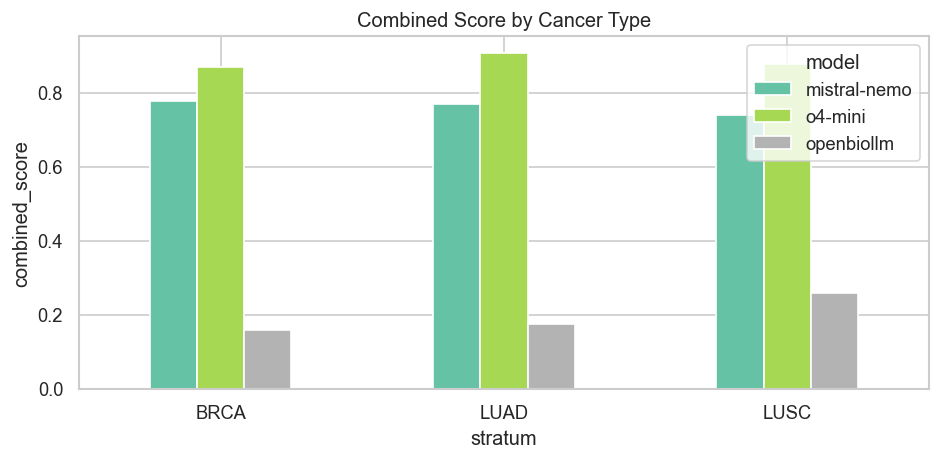

In [193]:
# 13.1 Combined score by cancer type
ct_all = pd.concat([
    stratified_mixed_df(preds_o4mini_styled,     ground_truth_styled, "cancer_type", "o4-mini"),
    stratified_mixed_df(preds_llama3_styled,     ground_truth_styled, "cancer_type", "mistral-nemo"),
    stratified_mixed_df(preds_openbiollm_styled, ground_truth_styled, "cancer_type", "openbiollm"),
], ignore_index=True)

if not ct_all.empty:
    pivot_ct = ct_all.pivot(index="stratum", columns="model", values="combined_score")
    display(pivot_ct.style
        .background_gradient(cmap="RdYlGn", vmin=0, vmax=1).format(precision=3)
        .set_caption("Combined score by cancer type"))
    pivot_ct.plot(kind="bar", figsize=(8, 4), colormap="Set2")
    plt.title("Combined Score by Cancer Type")
    plt.ylabel("combined_score")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


model,mistral-nemo,o4-mini,openbiollm
stratum,,,
mixed,0.755,0.884,0.157
narrative,0.781,0.871,0.407
synoptic,0.785,0.880,0.179


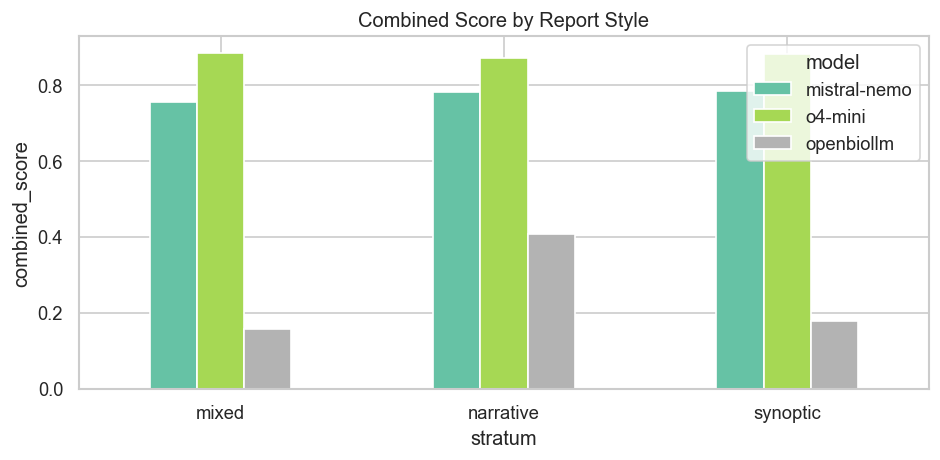

In [194]:
# 13.2 Combined score by report style
rs_all = pd.concat([
    stratified_mixed_df(preds_o4mini_styled,     ground_truth_styled, "report_style", "o4-mini"),
    stratified_mixed_df(preds_llama3_styled,     ground_truth_styled, "report_style", "mistral-nemo"),
    stratified_mixed_df(preds_openbiollm_styled, ground_truth_styled, "report_style", "openbiollm"),
], ignore_index=True)

if not rs_all.empty:
    pivot_rs = rs_all.pivot(index="stratum", columns="model", values="combined_score")
    display(pivot_rs.style
        .background_gradient(cmap="RdYlGn", vmin=0, vmax=1).format(precision=3)
        .set_caption("Combined score by report style"))
    pivot_rs.plot(kind="bar", figsize=(8, 4), colormap="Set2")
    plt.title("Combined Score by Report Style")
    plt.ylabel("combined_score")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


In [195]:
from src.evaluation.metrics import compute_field_null_rates, compute_m_null_rate

# 13.3 TNM null-rate drift
null_rows = []
for model_label, preds in [
    ("o4-mini",      preds_o4mini),
    ("mistral-nemo", preds_llama3),
    ("openbiollm",   preds_openbiollm),
]:
    if not preds:
        continue
    nr = compute_field_null_rates(preds)
    null_rows.append({
        "model":          model_label,
        "T null rate":    nr.get("null_rate_tnm_stage_T", 0),
        "N null rate":    nr.get("null_rate_tnm_stage_N", 0),
        "M null rate":    nr.get("null_rate_tnm_stage_M", 0),
        "M drift guard":  compute_m_null_rate(preds),
    })

null_df = pd.DataFrame(null_rows).set_index("model")
display(null_df.style
    .background_gradient(
        subset=["T null rate", "N null rate", "M null rate", "M drift guard"],
        cmap="Reds", vmin=0, vmax=1)
    .format("{:.1%}")
    .set_caption("TNM null rates per model (higher = model omitting the field more often)"))


,T null rate,N null rate,M null rate,M drift guard
model,,,,
o4-mini,8.9%,11.7%,52.2%,52.2%
mistral-nemo,19.4%,25.6%,66.7%,66.7%
openbiollm,81.7%,81.7%,93.3%,93.3%


In [196]:
from src.evaluation.semantic import parse_grade

# 13.4 Tumor grade deep-dive
gt_grades       = [r.get("tumor_grade") for r in ground_truth if r.get("tumor_grade")]
gt_grade_counts = pd.Series(gt_grades).value_counts().head(10)

grade_rows = []
for gt_val in gt_grade_counts.index:
    row = {
        "GT grade":  gt_val,
        "GT count":  gt_grade_counts[gt_val],
        "canonical": parse_grade(gt_val),
    }
    matching_rids = {r["report_id"] for r in ground_truth if r.get("tumor_grade") == gt_val}
    for model_label, preds in [
        ("o4-mini",      preds_o4mini),
        ("mistral-nemo", preds_llama3),
        ("openbiollm",   preds_openbiollm),
    ]:
        if not preds:
            row[f"{model_label} top preds"] = ""
            row[f"{model_label} OOV"]       = 0
            continue
        pred_map  = {r["report_id"]: r for r in preds}
        pred_vals = [pred_map[rid].get("tumor_grade") for rid in matching_rids if rid in pred_map]
        top_pred  = pd.Series([v for v in pred_vals if v]).value_counts().head(3).to_dict()
        oov_count = sum(
            1 for r in preds
            if r.get("report_id") in matching_rids
            for flag in (r.get("hallucination_flags") or [])
            if flag.startswith("unrecognised_grade")
        )
        row[f"{model_label} top preds"] = ", ".join(f"{k}({v})" for k, v in top_pred.items()) or "(null)"
        row[f"{model_label} OOV"]       = oov_count
    grade_rows.append(row)

display(pd.DataFrame(grade_rows).set_index("GT grade")
    .style.set_caption("Tumor grade: GT values vs model predictions and OOV flags"))


,GT count,canonical,o4-mini top preds,o4-mini OOV,mistral-nemo top preds,mistral-nemo OOV,openbiollm top preds,openbiollm OOV
GT grade,,,,,,,,
Grade 2,45,G2,"Grade 2(44), Grade 3(1)",0,"Grade 2(39), Grade 2/3(1), Grade II of III(1)",2,"Grade 3(7), Grade 2(5), Grade II (of III)(1)",3
Grade 3,31,G3,Grade 3(30),0,"Grade 3(25), Grade 2(2), Grade II(1)",3,Grade 3(8),0
Grade 2 (moderately differentiated),26,G2,"moderately differentiated(15), Grade 2(10), poorly differentiated(1)",0,"Grade 2(11), Grade 2 (moderately differentiated)(2), Grade 2/3 (moderately differentiated)(1)",4,"Grade 3(2), moderately differentiated(1)",0
Grade 3 (poorly differentiated),21,G3,"poorly differentiated(18), Grade 3(3)",0,"Grade 3(8), Grade 3 (poorly differentiated)(1)",1,(null),0
Grade 1,11,G1,Grade 1(10),0,"Grade 1(8), Grade 1 (good nuclear grade)(1)",1,(null),0
Grade 1 (well differentiated),5,G1,"well differentiated(4), Grade 1(1)",0,Grade 1(3),0,(null),0
Grade 2–3 (moderately to poorly differentiated),2,G2-G3,poorly differentiated(2),0,"Grade 2-3(1), Grade 3(1)",0,(null),0
Grade 4,2,G4,Grade 4(1),0,Grade 4(1),0,Grade 4(1),0
Grade 2–3 (histologic grade II-III/III),1,G2-G3,Grade 3(1),0,Grade II-III/III(1),1,(null),0


## 14. Record Inspector: GT vs Prediction

Bottom records by mean `combined_score` across all 3 models. The summary table gives a quick overview; the card printout lets you read each record's field-level breakdown alongside extraction notes and flags.


In [197]:
def _per_record_combined(preds, golds):
    pred_map   = {r["report_id"]: r for r in preds}
    tnm_fields = [f for f in ALL_FIELDS if f not in SEMANTIC_FIELDS]
    rows = []
    for g in golds:
        rid = g["report_id"]
        p   = pred_map.get(rid, {})
        fs  = {}
        for f in SEMANTIC_FIELDS:
            pv, gv = get_field_value(p, f), get_field_value(g, f)
            if pv is None and gv is None:
                fs[f] = 1.0
            elif gv is not None and pv is None:
                fs[f] = 0.0
            elif gv is None and pv is not None:
                fs[f] = 0.0
            else:
                s = _sem_score(pv, gv, f)
                fs[f] = s if s is not None else 0.0
        for f in tnm_fields:
            pv = (get_field_value(p, f) or "").strip().lower()
            gv = (get_field_value(g, f) or "").strip().lower()
            fs[f] = 1.0 if pv == gv else 0.0
        total_w  = sum(FIELD_WEIGHTS[f] for f in ALL_FIELDS)
        combined = sum(FIELD_WEIGHTS[f] * fs[f] for f in ALL_FIELDS) / total_w
        rows.append({"report_id": rid, "combined_score": round(combined, 4)})
    return pd.DataFrame(rows).set_index("report_id")


scores_o4 = _per_record_combined(preds_o4mini,    ground_truth)
scores_ll = _per_record_combined(preds_llama3,    ground_truth)
scores_ob = _per_record_combined(preds_openbiollm, ground_truth)

combined_rec = pd.DataFrame({
    "o4-mini":      scores_o4["combined_score"],
    "mistral-nemo": scores_ll["combined_score"],
    "openbiollm":   scores_ob["combined_score"],
})
combined_rec["mean_combined"] = combined_rec.mean(axis=1)
combined_rec = combined_rec.sort_values("mean_combined")

gt_meta_df = pd.DataFrame([
    {"report_id": r["report_id"], "cancer_type": r.get("cancer_type"),
     "style": style_lookup.get(r["report_id"])}
    for r in ground_truth
]).set_index("report_id")
combined_rec = combined_rec.join(gt_meta_df)

print("Bottom 20 records by mean combined_score across all 3 models:")
pd.set_option("display.float_format", "{:.3f}".format)
display(combined_rec.head(20).style
    .background_gradient(
        subset=["o4-mini", "mistral-nemo", "openbiollm", "mean_combined"],
        cmap="RdYlGn", vmin=0, vmax=1)
    .format(precision=3))


Bottom 20 records by mean combined_score across all 3 models:


,o4-mini,mistral-nemo,openbiollm,mean_combined,cancer_type,style
report_id,,,,,,
TCGA-AO-A0J5.5EFC16F4-7FC7-479E-93F7-AEDC2D350A22,0.559,0.260,0.000,0.273,BRCA,mixed
TCGA-77-8133.6ddd0cb2-fea0-4b27-9468-ca4f085192d6,0.525,0.351,0.133,0.336,LUSC,mixed
TCGA-78-7542.07a2fac9-0532-442e-ae75-5a7cc5d298d4,0.600,0.417,0.067,0.361,LUAD,mixed
TCGA-AR-A2LQ.C3537961-4636-4BD1-BC89-892580B36E43,0.600,0.496,0.067,0.388,BRCA,narrative
TCGA-AO-A12C.7E9202F6-F2DB-4CC0-A10F-3D9A82E84242,0.645,0.459,0.067,0.390,BRCA,synoptic
TCGA-63-6202.b8730165-2c60-469b-ae9a-f630fd97016a,0.399,0.463,0.333,0.398,LUSC,synoptic
TCGA-E2-A1LG.08A790DE-B01D-4140-BB1C-B4844291D71E,0.961,0.176,0.067,0.401,BRCA,synoptic
TCGA-A7-A426.B644AEB6-7D46-4D4D-BA00-D42BCDDCB164,0.867,0.346,0.000,0.404,BRCA,mixed
TCGA-39-5016.7b50ffbc-010e-415b-8d85-b5639801e287,0.800,0.348,0.067,0.405,LUSC,synoptic


In [198]:
# Card printout — bottom 10 records
BOTTOM_N    = 10
bottom_rids = combined_rec.head(BOTTOM_N).index.tolist()
gt_lkp      = {r["report_id"]: r for r in ground_truth}
pred_lkp    = {
    "o4-mini":      {r["report_id"]: r for r in preds_o4mini},
    "mistral-nemo": {r["report_id"]: r for r in preds_llama3},
    "openbiollm":   {r["report_id"]: r for r in preds_openbiollm},
}
MODEL_ORDER = ["o4-mini", "mistral-nemo", "openbiollm"]
COL_W = 26

for rid in bottom_rids:
    gt   = gt_lkp.get(rid, {})
    sc   = combined_rec.loc[rid]
    meta = gt_meta_df.loc[rid] if rid in gt_meta_df.index else {}
    sep  = "─" * 86

    print(f"\n{sep}")
    print(f"  report_id: {rid}   cancer_type: {gt.get('cancer_type', '-')}   style: {meta.get('style', '-')}")
    score_str = "  ".join(f"{m}={sc[m]:.3f}" for m in MODEL_ORDER if m in sc.index)
    print(f"  combined_score:  {score_str}   (mean={sc['mean_combined']:.3f})")
    print(sep)

    header = f"  {'field':<22} {'GT':<{COL_W}}"
    for m in MODEL_ORDER:
        header += f" {m:<{COL_W}}"
    print(header)
    print("  " + "-" * (22 + (COL_W + 1) * (1 + len(MODEL_ORDER))))

    for field in ALL_FIELDS:
        gv      = str(get_field_value(gt, field) or "(null)")[:COL_W - 1]
        row_str = f"  {field:<22} {gv:<{COL_W}}"
        for m in MODEL_ORDER:
            pred = pred_lkp[m].get(rid, {})
            pv   = str(get_field_value(pred, field) or "(null)")[:COL_W - 1]
            row_str += f" {pv:<{COL_W}}"
        print(row_str)

    print()
    print("  hallucination_flags:")
    for m in MODEL_ORDER:
        pred  = pred_lkp[m].get(rid, {})
        flags = pred.get("hallucination_flags") or []
        print(f"    {(m + ':'):<20} {'; '.join(flags) if flags else chr(8212)}")

    print()
    print("  extraction_notes:")
    for m in MODEL_ORDER:
        pred = pred_lkp[m].get(rid, {})
        note = pred.get("extraction_notes") or "None"
        if len(note) > 220:
            note = note[:217] + "..."
        print(f"    {(m + ':'):<20} {note}")

    print()



──────────────────────────────────────────────────────────────────────────────────────
  report_id: TCGA-AO-A0J5.5EFC16F4-7FC7-479E-93F7-AEDC2D350A22   cancer_type: BRCA   style: mixed
  combined_score:  o4-mini=0.559  mistral-nemo=0.260  openbiollm=0.000   (mean=0.273)
──────────────────────────────────────────────────────────────────────────────────────
  field                  GT                         o4-mini                    mistral-nemo               openbiollm                
  ----------------------------------------------------------------------------------------------------------------------------------
  primary_site           right breast (all four qu  right breast, all four qu  right breast, all four qu  (null)                    
  specimen_type          modified radical mastecto  modified radical mastecto  modified radical mastecto  (null)                    
  histological_diagnosis invasive carcinoma with m  invasive carcinoma         invasive carcinoma (mixed  (nu

## 15. OpenBioLLM Deep-Dive: Null Analysis

OpenBioLLM has the highest null rate across all models. This section breaks down:
1. **Null rate per field** — including `json_failed` records (model output couldn't be parsed) vs. valid records where the model returned `null`.
2. **Extraction notes for null records** — what the model wrote when it returned `null` for at least one field.

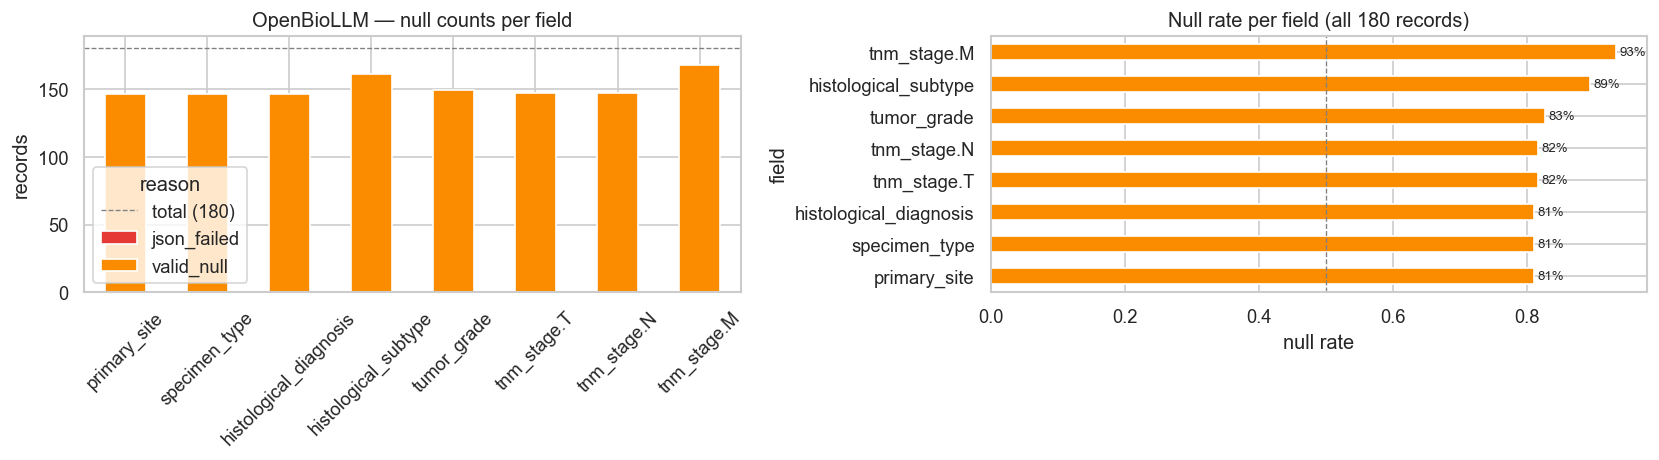


json_failed records: 0 / 180
valid records with ≥1 null field: 176 / 180


,null_total,null_rate,valid_null,valid_null_rate
field,,,,
primary_site,146,81.1%,146,81.1%
specimen_type,146,81.1%,146,81.1%
histological_diagnosis,146,81.1%,146,81.1%
histological_subtype,161,89.4%,161,89.4%
tumor_grade,149,82.8%,149,82.8%
tnm_stage.T,147,81.7%,147,81.7%
tnm_stage.N,147,81.7%,147,81.7%
tnm_stage.M,168,93.3%,168,93.3%


In [199]:
# 15.1  Null rate per field — valid-but-null vs json_failed
from src.evaluation.metrics import ALL_FIELDS, get_field_value

ob_valid   = [r for r in preds_openbiollm if r.get('validation_status') != 'json_failed']
ob_failed  = [r for r in preds_openbiollm if r.get('validation_status') == 'json_failed']
total      = len(preds_openbiollm)

null_rows = []
for field in ALL_FIELDS:
    valid_nulls = sum(1 for r in ob_valid if get_field_value(r, field) is None)
    null_rows.append({
        'field':          field,
        'json_failed':    len(ob_failed),
        'valid_null':     valid_nulls,
        'null_total':     len(ob_failed) + valid_nulls,
        'null_rate':      (len(ob_failed) + valid_nulls) / total,
        'valid_null_rate': valid_nulls / len(ob_valid) if ob_valid else 0,
    })

null_df = pd.DataFrame(null_rows).set_index('field')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: stacked bar — json_failed vs valid_null
ax = axes[0]
null_df[['json_failed', 'valid_null']].plot(
    kind='bar', stacked=True, ax=ax,
    color=['#E53935', '#FB8C00'],
)
ax.set_title('OpenBioLLM — null counts per field')
ax.set_xlabel('')
ax.set_ylabel('records')
ax.axhline(total, color='grey', linestyle='--', linewidth=0.8, label=f'total ({total})')
ax.legend(title='reason')
ax.tick_params(axis='x', rotation=45)

# Right: null rate (all records)
ax2 = axes[1]
null_df['null_rate'].sort_values(ascending=True).plot(
    kind='barh', ax=ax2, color='#FB8C00'
)
ax2.set_title('Null rate per field (all 180 records)')
ax2.set_xlabel('null rate')
ax2.axvline(0.5, color='grey', linestyle='--', linewidth=0.8)
for i, v in enumerate(null_df['null_rate'].sort_values(ascending=True)):
    ax2.text(v + 0.005, i, f'{v:.0%}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

print(f'\njson_failed records: {len(ob_failed)} / {total}')
print(f'valid records with ≥1 null field: {sum(1 for r in ob_valid if any(get_field_value(r, f) is None for f in ALL_FIELDS))} / {len(ob_valid)}')
display(null_df[['null_total', 'null_rate', 'valid_null', 'valid_null_rate']].style
    .format({'null_rate': '{:.1%}', 'valid_null_rate': '{:.1%}'})
    .background_gradient(subset=['null_rate'], cmap='Oranges')
    .set_caption('OpenBioLLM null analysis (5-shot, n=180)'))

### 15.2 Extraction Notes for Null Records

For each valid record where the model returned `null` on at least one field, shows which fields were null and the model's `extraction_notes`.

In [200]:
# 15.2  Extraction notes for records with null fields (valid records only)
notes_rows = []
for r in ob_valid:
    null_fields = [f for f in ALL_FIELDS if get_field_value(r, f) is None]
    if not null_fields:
        continue
    notes_rows.append({
        'report_id':      r['report_id'],
        'cancer_type':    r.get('cancer_type', ''),
        'null_fields':    ', '.join(null_fields),
        'n_null':         len(null_fields),
        'extraction_notes': r.get('extraction_notes') or '—',
    })

notes_df = (
    pd.DataFrame(notes_rows)
    .sort_values('n_null', ascending=False)
    .reset_index(drop=True)
)

print(f'Valid records with ≥1 null field: {len(notes_df)}')
print(f'Records with extraction_notes present: {(notes_df["extraction_notes"] != "—").sum()}')
print()

pd.set_option('display.max_colwidth', 10)
display(
    notes_df[['report_id', 'cancer_type', 'n_null', 'null_fields', 'extraction_notes']]
    .style
    .background_gradient(subset=['n_null'], cmap='Oranges')
    .set_caption('OpenBioLLM: valid records with null fields and their extraction notes')
)

Valid records with ≥1 null field: 176
Records with extraction_notes present: 31



,report_id,cancer_type,n_null,null_fields,extraction_notes
0,TCGA-50-8460.fc79e8c5-c79b-46d3-ab41-03399a68999a,LUAD,8,"primary_site, specimen_type, histological_diagnosis, histological_subtype, tumor_grade, tnm_stage.T, tnm_stage.N, tnm_stage.M",—
1,TCGA-66-2793.c2a1ad10-926c-4bab-9a34-467b3496a453,LUSC,8,"primary_site, specimen_type, histological_diagnosis, histological_subtype, tumor_grade, tnm_stage.T, tnm_stage.N, tnm_stage.M",—
2,TCGA-55-7227.7910979d-a635-4ef5-ab00-84df0455df66,LUAD,8,"primary_site, specimen_type, histological_diagnosis, histological_subtype, tumor_grade, tnm_stage.T, tnm_stage.N, tnm_stage.M",—
3,TCGA-55-7914.eaabadac-ea5e-47c3-9db7-d2c0c77b7b68,LUAD,8,"primary_site, specimen_type, histological_diagnosis, histological_subtype, tumor_grade, tnm_stage.T, tnm_stage.N, tnm_stage.M",—
4,TCGA-91-8497.e393a314-6d4d-41f4-a9d3-7d67ab25713b,LUAD,8,"primary_site, specimen_type, histological_diagnosis, histological_subtype, tumor_grade, tnm_stage.T, tnm_stage.N, tnm_stage.M",—
5,TCGA-55-6978.3e3c1e82-ee09-4eeb-873a-9b6580274f97,LUAD,8,"primary_site, specimen_type, histological_diagnosis, histological_subtype, tumor_grade, tnm_stage.T, tnm_stage.N, tnm_stage.M",—
6,TCGA-21-1080.c5e7cfa9-2ee0-455f-80d2-e5ecc721d1ec,LUSC,8,"primary_site, specimen_type, histological_diagnosis, histological_subtype, tumor_grade, tnm_stage.T, tnm_stage.N, tnm_stage.M",—
7,TCGA-39-5021.84d7dc8e-29cd-4adc-93ea-cda77cf855b4,LUSC,8,"primary_site, specimen_type, histological_diagnosis, histological_subtype, tumor_grade, tnm_stage.T, tnm_stage.N, tnm_stage.M",—
8,TCGA-34-5236.8aadcd05-f598-4c12-87eb-6769bbf24b51,LUSC,8,"primary_site, specimen_type, histological_diagnosis, histological_subtype, tumor_grade, tnm_stage.T, tnm_stage.N, tnm_stage.M",—
9,TCGA-77-8133.6ddd0cb2-fea0-4b27-9468-ca4f085192d6,LUSC,8,"primary_site, specimen_type, histological_diagnosis, histological_subtype, tumor_grade, tnm_stage.T, tnm_stage.N, tnm_stage.M",—
